DATASET CONFIGURATION

In [1]:
from torch.optim.lr_scheduler import ReduceLROnPlateau
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
import torch
from torch import nn
import torch.nn.functional as F



from cesnet_datazoo.datasets import CESNET_TLS22
from cesnet_datazoo.config import DatasetConfig, AppSelection
from cesnet_datazoo.config import ScalerEnum

import random
import numpy as np

dataset = CESNET_TLS22("../datasets/CESNET-TLS22/", size="XS")
dataset_config = DatasetConfig(
    dataset=dataset,
    apps_selection=AppSelection.TOPX_KNOWN,
    apps_selection_topx=10,
    train_period_name="W-2021-40",
    test_period_name="W-2021-41",
    psizes_scaler=ScalerEnum.MINMAX,
    ipt_scaler=ScalerEnum.MINMAX,
    flowstats_scaler= ScalerEnum.MINMAX,
    train_dataloader_order= 'random',
    
    
    batch_size=32,
)

dataset.set_dataset_config_and_initialize(dataset_config)

train_dl = dataset.get_train_dataloader()
val_dl = dataset.get_val_dataloader()
test_dl = dataset.get_test_dataloader()



MASKING FUNCTION

In [ ]:
def mask_data(sequences, mask_percentage=0.15):
    masked_sequences = sequences.clone()
    num_to_mask = int(torch.ceil(torch.tensor(mask_percentage) * sequences.shape[1] * sequences.shape[2]))
    
    mask_indices = [(i, torch.randint(0, sequences.shape[1], (num_to_mask,)), 
                     torch.randint(0, sequences.shape[2], (num_to_mask,))) 
                    for i in range(sequences.shape[0])]
    
    for i, times, features in mask_indices:
        masked_sequences[i, times, features] = 0  # Zero masking
    device = sequences.device
    return masked_sequences.to(device)


MASK MODEL

In [ ]:
class MaskModel(nn.Module):
    def __init__(self, num_layers, hidden_dim_mask,):
        super(MaskModel, self).__init__()
        self.num_layers = num_layers
        self.hidden_dim_mask = hidden_dim_mask

        #LSTM mask
        self.lstm_mask = nn.LSTM(3, hidden_dim_mask, num_layers, batch_first=True,bidirectional=True)
        #fully connected for mask
        self.fc_mask = nn.Linear(hidden_dim_mask*2, 3)  # Output size matches input feature size
    
         # Pooling layer for mask features
        self.pooling_mask = nn.AvgPool1d(kernel_size=2, stride=2)
        

        
    def forward(self, x_masked):

        h0 = torch.zeros(self.num_layers*2, x_masked.size(0), self.hidden_dim_mask).to(x_masked.device)
        c0 = torch.zeros(self.num_layers*2, x_masked.size(0), self.hidden_dim_mask).to(x_masked.device)
        
        # Forward propagate LSTM
        masking_predictions, _ = self.lstm_mask(x_masked, (h0, c0))  # out: tensor of shape (batch_size, seq_length, hidden_size)
        
        # Decode the hidden state of all time steps
        masking_predictions = self.fc_mask(masking_predictions)
        return masking_predictions 
    def extract_features(self, x_masked):
        
        h0 = torch.zeros(self.num_layers*2, x_masked.size(0), self.hidden_dim_mask).to(x_masked.device)
        c0 = torch.zeros(self.num_layers*2, x_masked.size(0), self.hidden_dim_mask).to(x_masked.device)
        masking_predictions, _ = self.lstm_mask(x_masked, (h0, c0))
        # Apply pooling to mask features for feature extraction
        masking_predictions_pooled = self.pooling_mask(masking_predictions.permute(0, 2, 1)).permute(0, 2, 1)
        
        # Return the LSTM outputs directly as features
        return masking_predictions_pooled

    


FUNCTIONS FOR CONTRASTIVE LEARNING

In [ ]:
def generate_negative_sequences(sequences):
    """
    Generates negative sequences by shuffling the batch. Ensures no sequence
    is the same as the original sequence at the same index.

    Parameters:
    - sequences: Tensor of shape [batch_size, seq_len], representing the input sequences.

    Returns:
    - shuffled_sequences: Tensor of shape [batch_size, seq_len], where each sequence is different from
      the corresponding sequence in the original batch.
    """
    batch_size = sequences.size(0)

    # Initialize an array of indices
    idx = torch.arange(batch_size)
    
    # Ensure no index remains the same after shuffling
    while True:
        shuffled_idx = idx[torch.randperm(batch_size)]
        if not (shuffled_idx == idx).any():
            break

    # Use the shuffled indices to reorder sequences
    shuffled_sequences = sequences[shuffled_idx]


    return shuffled_sequences


In [ ]:
def l2_normalize(embeddings):
    """Applies L2 normalization to embeddings."""
    return embeddings / (embeddings.norm(dim=1, keepdim=True) + 1e-12)

def infoNCE_loss(anchor_embeddings, positive_embeddings, negative_embeddings, temperature=0.5):
    """
    Calculates the InfoNCE loss with normalized embeddings and separate handling
    for positive and negative similarities.

    Args:
    - anchor_embeddings: Embeddings of the original sequences.
    - positive_embeddings: Embeddings of the masked versions of the original sequences.
    - negative_embeddings: Embeddings of masked versions of different sequences.
    - temperature: A scaling factor to manage the sharpness of the distribution.

    Returns:
    - The calculated InfoNCE loss.
    """
    # Normalize embeddings
    anchor_embeddings = l2_normalize(anchor_embeddings)
    positive_embeddings = l2_normalize(positive_embeddings)
    negative_embeddings = l2_normalize(negative_embeddings)

    # Calculate positive similarity
     # InfoNCE loss
    positive_term = torch.sum(anchor_embeddings * positive_embeddings, dim=1) / temperature
    negative_term = torch.logsumexp(torch.matmul(anchor_embeddings, negative_embeddings.T) / temperature, dim=1)



    loss = -positive_term + negative_term

    return loss.mean()



In [ ]:
def print_cosine_similarity(embedding1, embedding2):
    # Ensure the embeddings are floats for torch.matmul operation
    embedding1 = embedding1.float()
    embedding2 = embedding2.float()
    
    # Normalize the embeddings to unit vectors
    embedding1_norm = F.normalize(embedding1, p=2, dim=0)
    embedding2_norm = F.normalize(embedding2, p=2, dim=0)
    
    # Calculate cosine similarity as dot product of the normalized vectors
    cosine_sim = torch.dot(embedding1_norm, embedding2_norm)
    
    print(f"Cosine Similarity: {cosine_sim.item()}")

MASK MODEL TRAINING

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
weights = np.arange(0, 1.1, 0.1)
for mask_weight in weights:
        contrastive_weight = 1 - mask_weight
        

        # Instantiate the model
        model = MaskModel(hidden_dim_mask=100, num_layers=2)
        model_name = f'model_contrastive={contrastive_weight:.1f}_mask={mask_weight:.1f}.pth'

        model.to(device)

        # Loss function
        criterion_mask = nn.MSELoss()

        # Optimizer
        optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

        # Learning rate scheduler
        scheduler = ReduceLROnPlateau(optimizer, 'min', factor=0.1, patience=3, verbose=True)

        # Training parameters
        num_epochs = 30
        patience = 2
        best_val_loss = float('inf')
        epochs_without_improvement = 0

        # Training loop
        for epoch in range(num_epochs):
            model.train()
            train_losses = []
            for i, (_, ppi, additional_features, y) in enumerate(train_dl):  # Adjust as per your dataset
                ppi = torch.from_numpy(ppi).float().to(device)
                ppi = ppi.transpose(1, 2)
                original_ppi = ppi.clone()

                optimizer.zero_grad()
                

                masked_ppi = mask_data(ppi,mask_percentage=0.25) 
               
                anchor_embeddings = model.extract_features(ppi).flatten(start_dim = -2)
                negative_sequences = generate_negative_sequences(ppi)
                negative_sequences = mask_data(negative_sequences,mask_percentage=0.5)
                negative_embeddings = model.extract_features(negative_sequences).flatten(start_dim = -2)
                positive_embeddings = model.extract_features(masked_ppi).flatten(start_dim = -2)
                
                contrastive_loss = infoNCE_loss(anchor_embeddings,positive_embeddings,negative_embeddings,temperature= 0.3)
                

                predicted_masks = model(masked_ppi)
                loss_mask = criterion_mask(predicted_masks, original_ppi)
                total_loss =contrastive_weight * contrastive_loss + mask_weight * loss_mask
                train_losses.append(total_loss.item())
                total_loss.backward()
                optimizer.step()

                if i % 1000 == 0:
                    print(f"Epoch [{epoch+1}/{num_epochs}], Step [{i}], Loss: {total_loss.item()}")
                    print_cosine_similarity(anchor_embeddings[0],positive_embeddings[0])
                    print_cosine_similarity(anchor_embeddings[0],negative_embeddings[0])


            # Validation phase
            val_losses = []
            model.eval()
            with torch.no_grad():
                for i, (_, ppi, additional_features, y) in enumerate(val_dl):  # Adjust as per your dataset
                    ppi = torch.from_numpy(ppi).float().to(device)
                    ppi = ppi.transpose(1, 2)
                    original_ppi = ppi.clone()

                    optimizer.zero_grad()
                    

                    masked_ppi = mask_data(ppi,mask_percentage=0.25) 
                    
                    anchor_embeddings = model.extract_features(ppi).flatten(start_dim = -2)
                    negative_sequences = generate_negative_sequences(ppi)
                    negative_sequences = mask_data(negative_sequences,mask_percentage=0.5)
                    negative_embeddings = model.extract_features(negative_sequences).flatten(start_dim = -2)
                    positive_embeddings = model.extract_features(masked_ppi).flatten(start_dim = -2)
                    
                    contrastive_loss = infoNCE_loss(anchor_embeddings,positive_embeddings,negative_embeddings,temperature=0.3)
                    

                    predicted_masks = model(masked_ppi)
                    mask_loss = criterion_mask(predicted_masks, original_ppi)
                    val_loss = contrastive_weight * contrastive_loss + mask_weight * loss_mask
                    val_losses.append(val_loss.item())

            avg_val_loss = np.mean(val_losses)
            print(f"Epoch [{epoch+1}/{num_epochs}], Validation Loss: {avg_val_loss}")
            scheduler.step(avg_val_loss)

            # Early stopping
            if avg_val_loss < best_val_loss:
                best_val_loss = avg_val_loss
                epochs_without_improvement = 0
                # Save the model checkpoint
                torch.save(model.state_dict(), model_name)
            else:
                epochs_without_improvement += 1
                if epochs_without_improvement >= patience:
                    print("Early stopping triggered.")
                    break



   



FEATURE EXTRACTION AND DOWNSTREAM TASK


Model saved as model_contrastive=0.7_mask=0.3.pth
Batch 0, features saved to extracted_features_mask_contrastive/features_batch_0.pt, labels saved to extracted_labels_mask_contrastive/labels_batch_0.pt
Batch 1000, features saved to extracted_features_mask_contrastive/features_batch_1000.pt, labels saved to extracted_labels_mask_contrastive/labels_batch_1000.pt
Batch 2000, features saved to extracted_features_mask_contrastive/features_batch_2000.pt, labels saved to extracted_labels_mask_contrastive/labels_batch_2000.pt
Batch 3000, features saved to extracted_features_mask_contrastive/features_batch_3000.pt, labels saved to extracted_labels_mask_contrastive/labels_batch_3000.pt
Batch 4000, features saved to extracted_features_mask_contrastive/features_batch_4000.pt, labels saved to extracted_labels_mask_contrastive/labels_batch_4000.pt
Batch 5000, features saved to extracted_features_mask_contrastive/features_batch_5000.pt, labels saved to extracted_labels_mask_contrastive/labels_batch_5

/root/miniconda3/lib/python3.12/site-packages/torch/optim/lr_scheduler.py:28: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn("The verbose parameter is deprecated. Please use get_last_lr() "


Epoch 0 Batch 0, Loss: 2.3091182708740234
Epoch 0 Batch 1000, Loss: 0.9326335191726685
Epoch 0 Batch 2000, Loss: 0.6449114680290222
Epoch 0 Batch 3000, Loss: 0.27827122807502747
Epoch 0 Batch 4000, Loss: 0.5204695463180542
Epoch 0 Batch 5000, Loss: 0.5639122724533081
Epoch 0 Batch 6000, Loss: 0.5452640056610107
Epoch 0 Batch 7000, Loss: 0.41949161887168884
Epoch 0 Batch 8000, Loss: 0.37623122334480286
Epoch 0 Batch 9000, Loss: 0.3185182213783264
Epoch 0 Batch 10000, Loss: 0.34381532669067383
Epoch 0 Batch 11000, Loss: 0.32643967866897583
Epoch 0 Batch 12000, Loss: 0.3944835960865021
Epoch 0 Batch 13000, Loss: 0.503409743309021
Epoch 0 Batch 14000, Loss: 0.551884114742279
Epoch 0 Batch 15000, Loss: 0.5842238068580627
Epoch 0 Batch 16000, Loss: 0.592574417591095
Epoch 0 Batch 17000, Loss: 0.25709083676338196
Epoch 0 Batch 18000, Loss: 0.18288585543632507
Epoch 0 Batch 19000, Loss: 0.26586365699768066
Epoch 0 Batch 20000, Loss: 0.14349932968616486
Epoch 0 Batch 21000, Loss: 0.479711741209

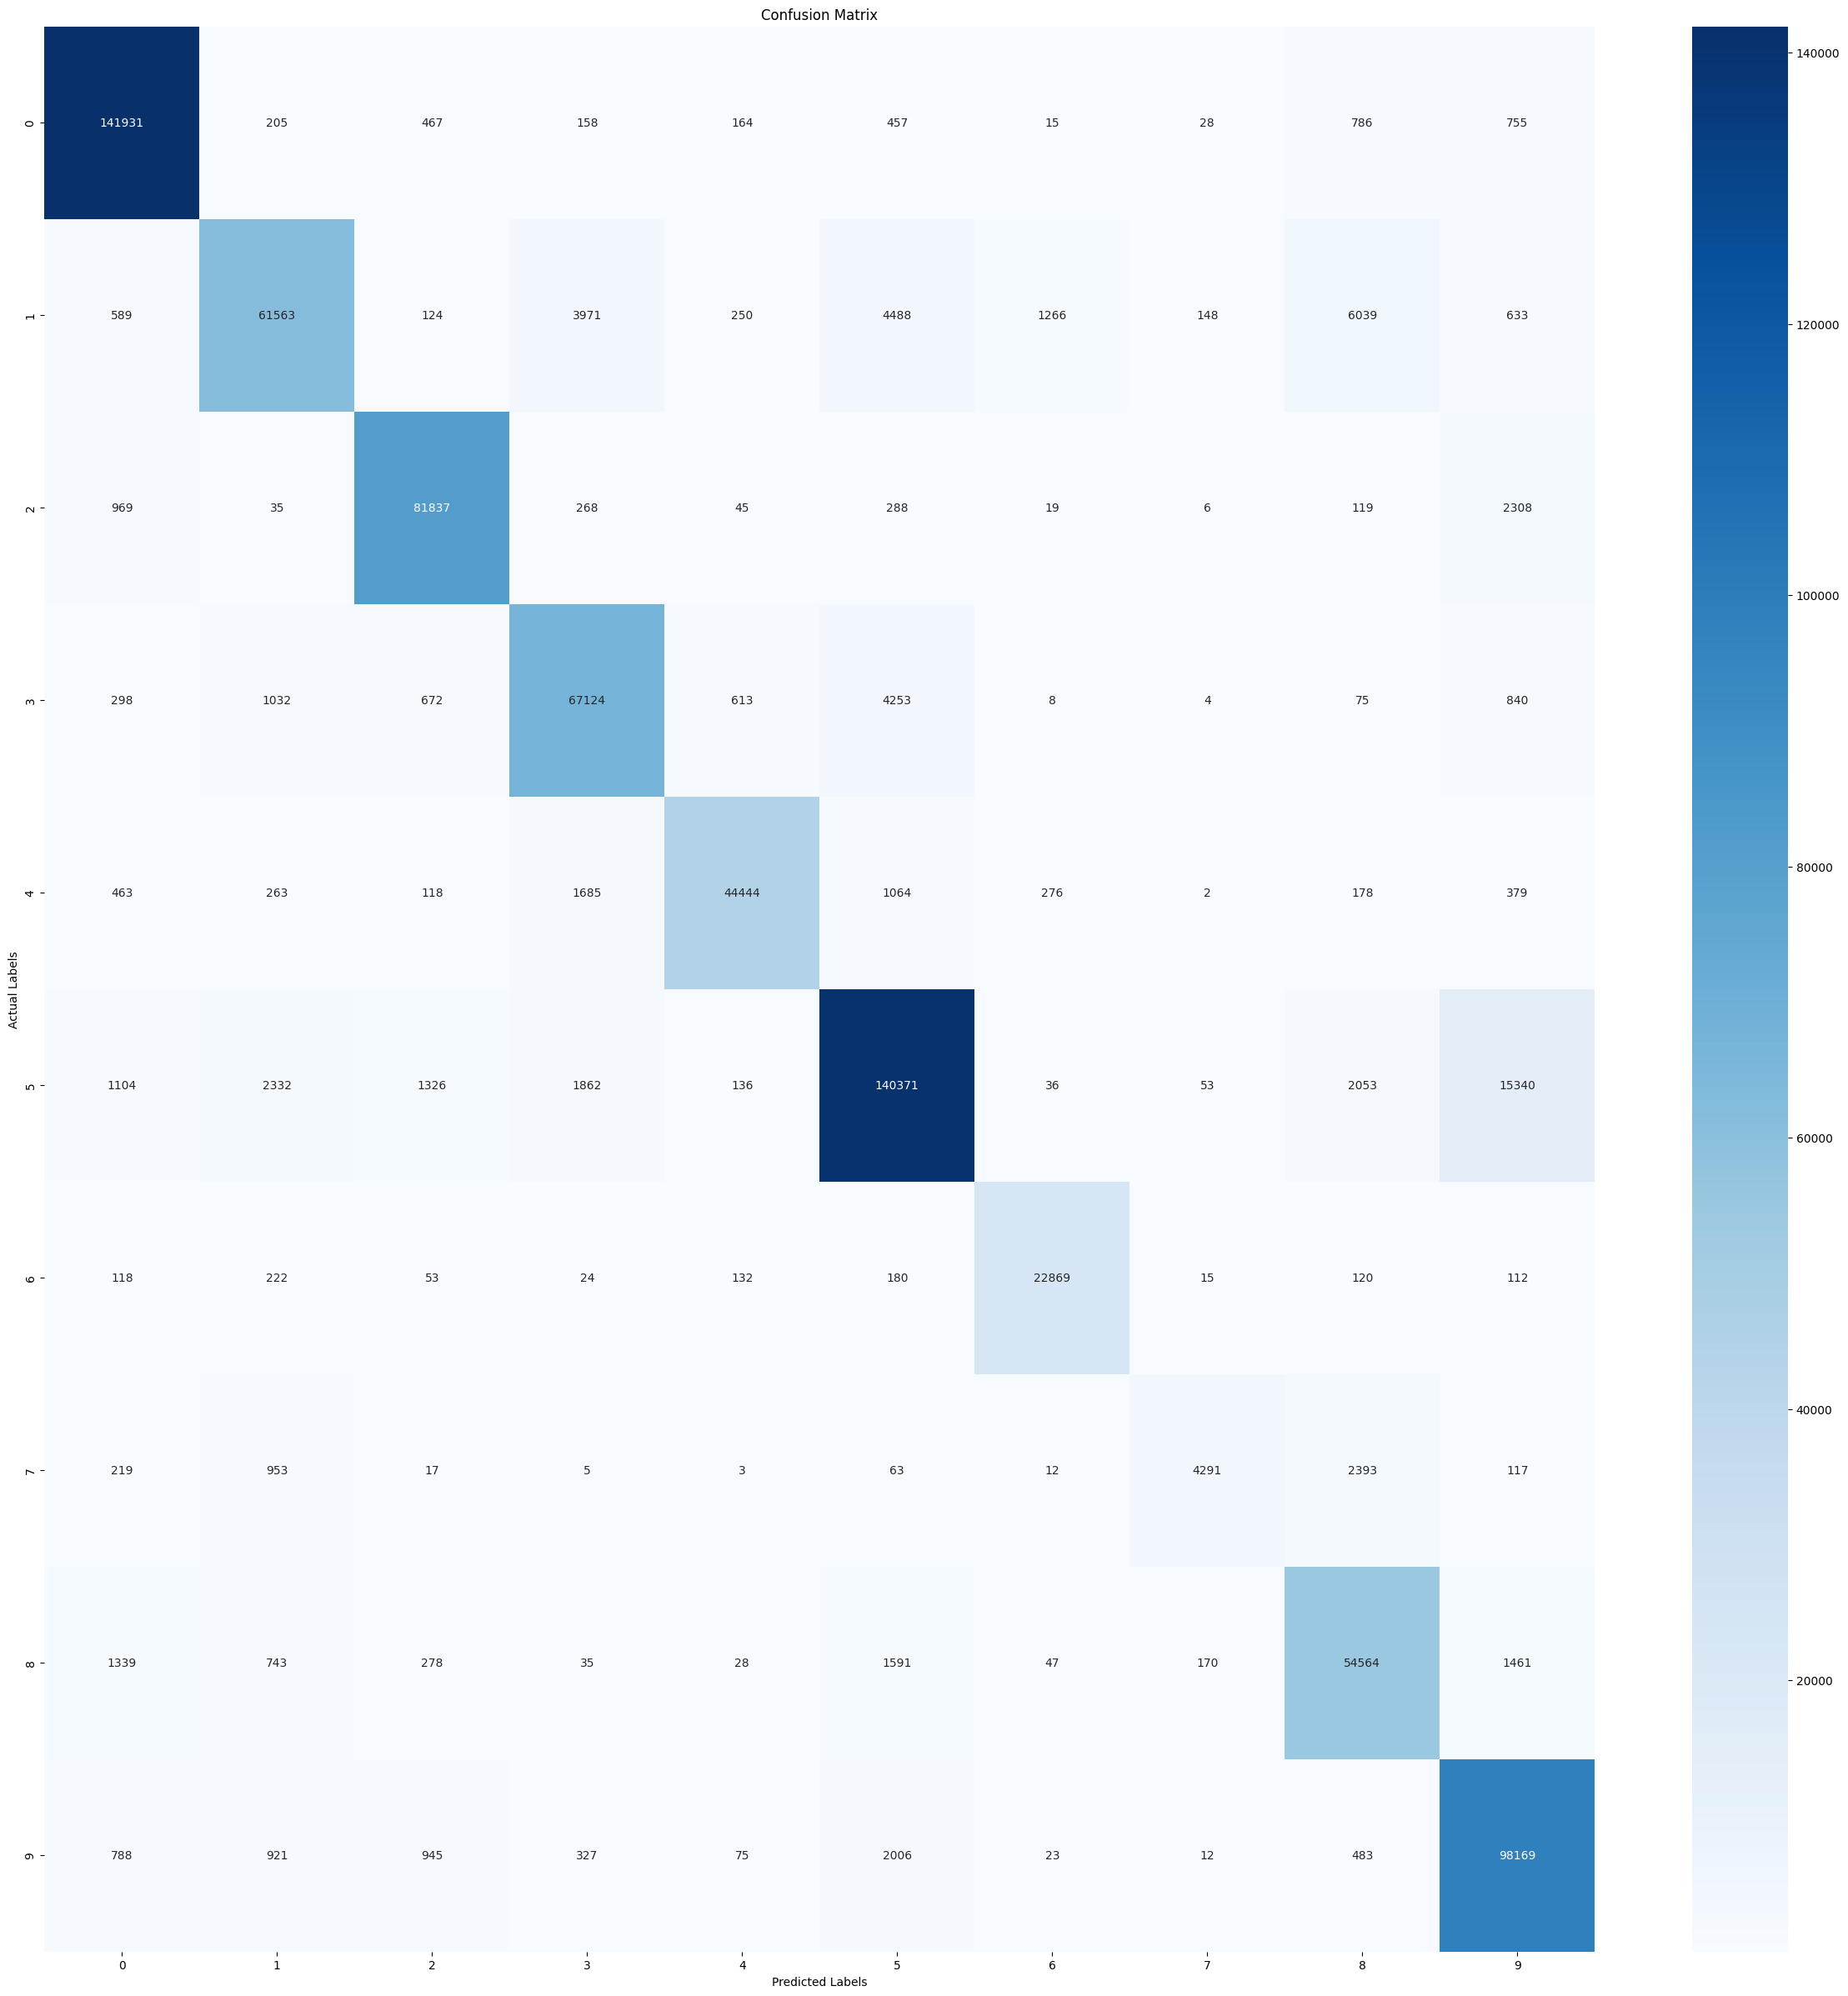

Model saved as model_contrastive=0.6_mask=0.4.pth
Batch 0, features saved to extracted_features_mask_contrastive/features_batch_0.pt, labels saved to extracted_labels_mask_contrastive/labels_batch_0.pt
Batch 1000, features saved to extracted_features_mask_contrastive/features_batch_1000.pt, labels saved to extracted_labels_mask_contrastive/labels_batch_1000.pt
Batch 2000, features saved to extracted_features_mask_contrastive/features_batch_2000.pt, labels saved to extracted_labels_mask_contrastive/labels_batch_2000.pt
Batch 3000, features saved to extracted_features_mask_contrastive/features_batch_3000.pt, labels saved to extracted_labels_mask_contrastive/labels_batch_3000.pt
Batch 4000, features saved to extracted_features_mask_contrastive/features_batch_4000.pt, labels saved to extracted_labels_mask_contrastive/labels_batch_4000.pt
Batch 5000, features saved to extracted_features_mask_contrastive/features_batch_5000.pt, labels saved to extracted_labels_mask_contrastive/labels_batch_5

/root/miniconda3/lib/python3.12/site-packages/torch/optim/lr_scheduler.py:28: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn("The verbose parameter is deprecated. Please use get_last_lr() "


Epoch 0 Batch 1000, Loss: 0.6027445197105408
Epoch 0 Batch 2000, Loss: 0.3677309453487396
Epoch 0 Batch 3000, Loss: 0.4600954055786133
Epoch 0 Batch 4000, Loss: 0.28119033575057983
Epoch 0 Batch 5000, Loss: 0.3965998888015747
Epoch 0 Batch 6000, Loss: 0.1725872904062271
Epoch 0 Batch 7000, Loss: 0.3003235459327698
Epoch 0 Batch 8000, Loss: 0.6274415254592896
Epoch 0 Batch 9000, Loss: 0.4601302742958069
Epoch 0 Batch 10000, Loss: 0.37177497148513794
Epoch 0 Batch 11000, Loss: 0.09296069294214249
Epoch 0 Batch 12000, Loss: 0.4069168269634247
Epoch 0 Batch 13000, Loss: 0.2484450489282608
Epoch 0 Batch 14000, Loss: 0.4246513247489929
Epoch 0 Batch 15000, Loss: 0.3497627377510071
Epoch 0 Batch 16000, Loss: 0.377299040555954
Epoch 0 Batch 17000, Loss: 0.38518303632736206
Epoch 0 Batch 18000, Loss: 0.496864914894104
Epoch 0 Batch 19000, Loss: 0.1625690907239914
Epoch 0 Batch 20000, Loss: 0.20549526810646057
Epoch 0 Batch 21000, Loss: 0.24317678809165955
Epoch [1/30], Average Validation Loss: 

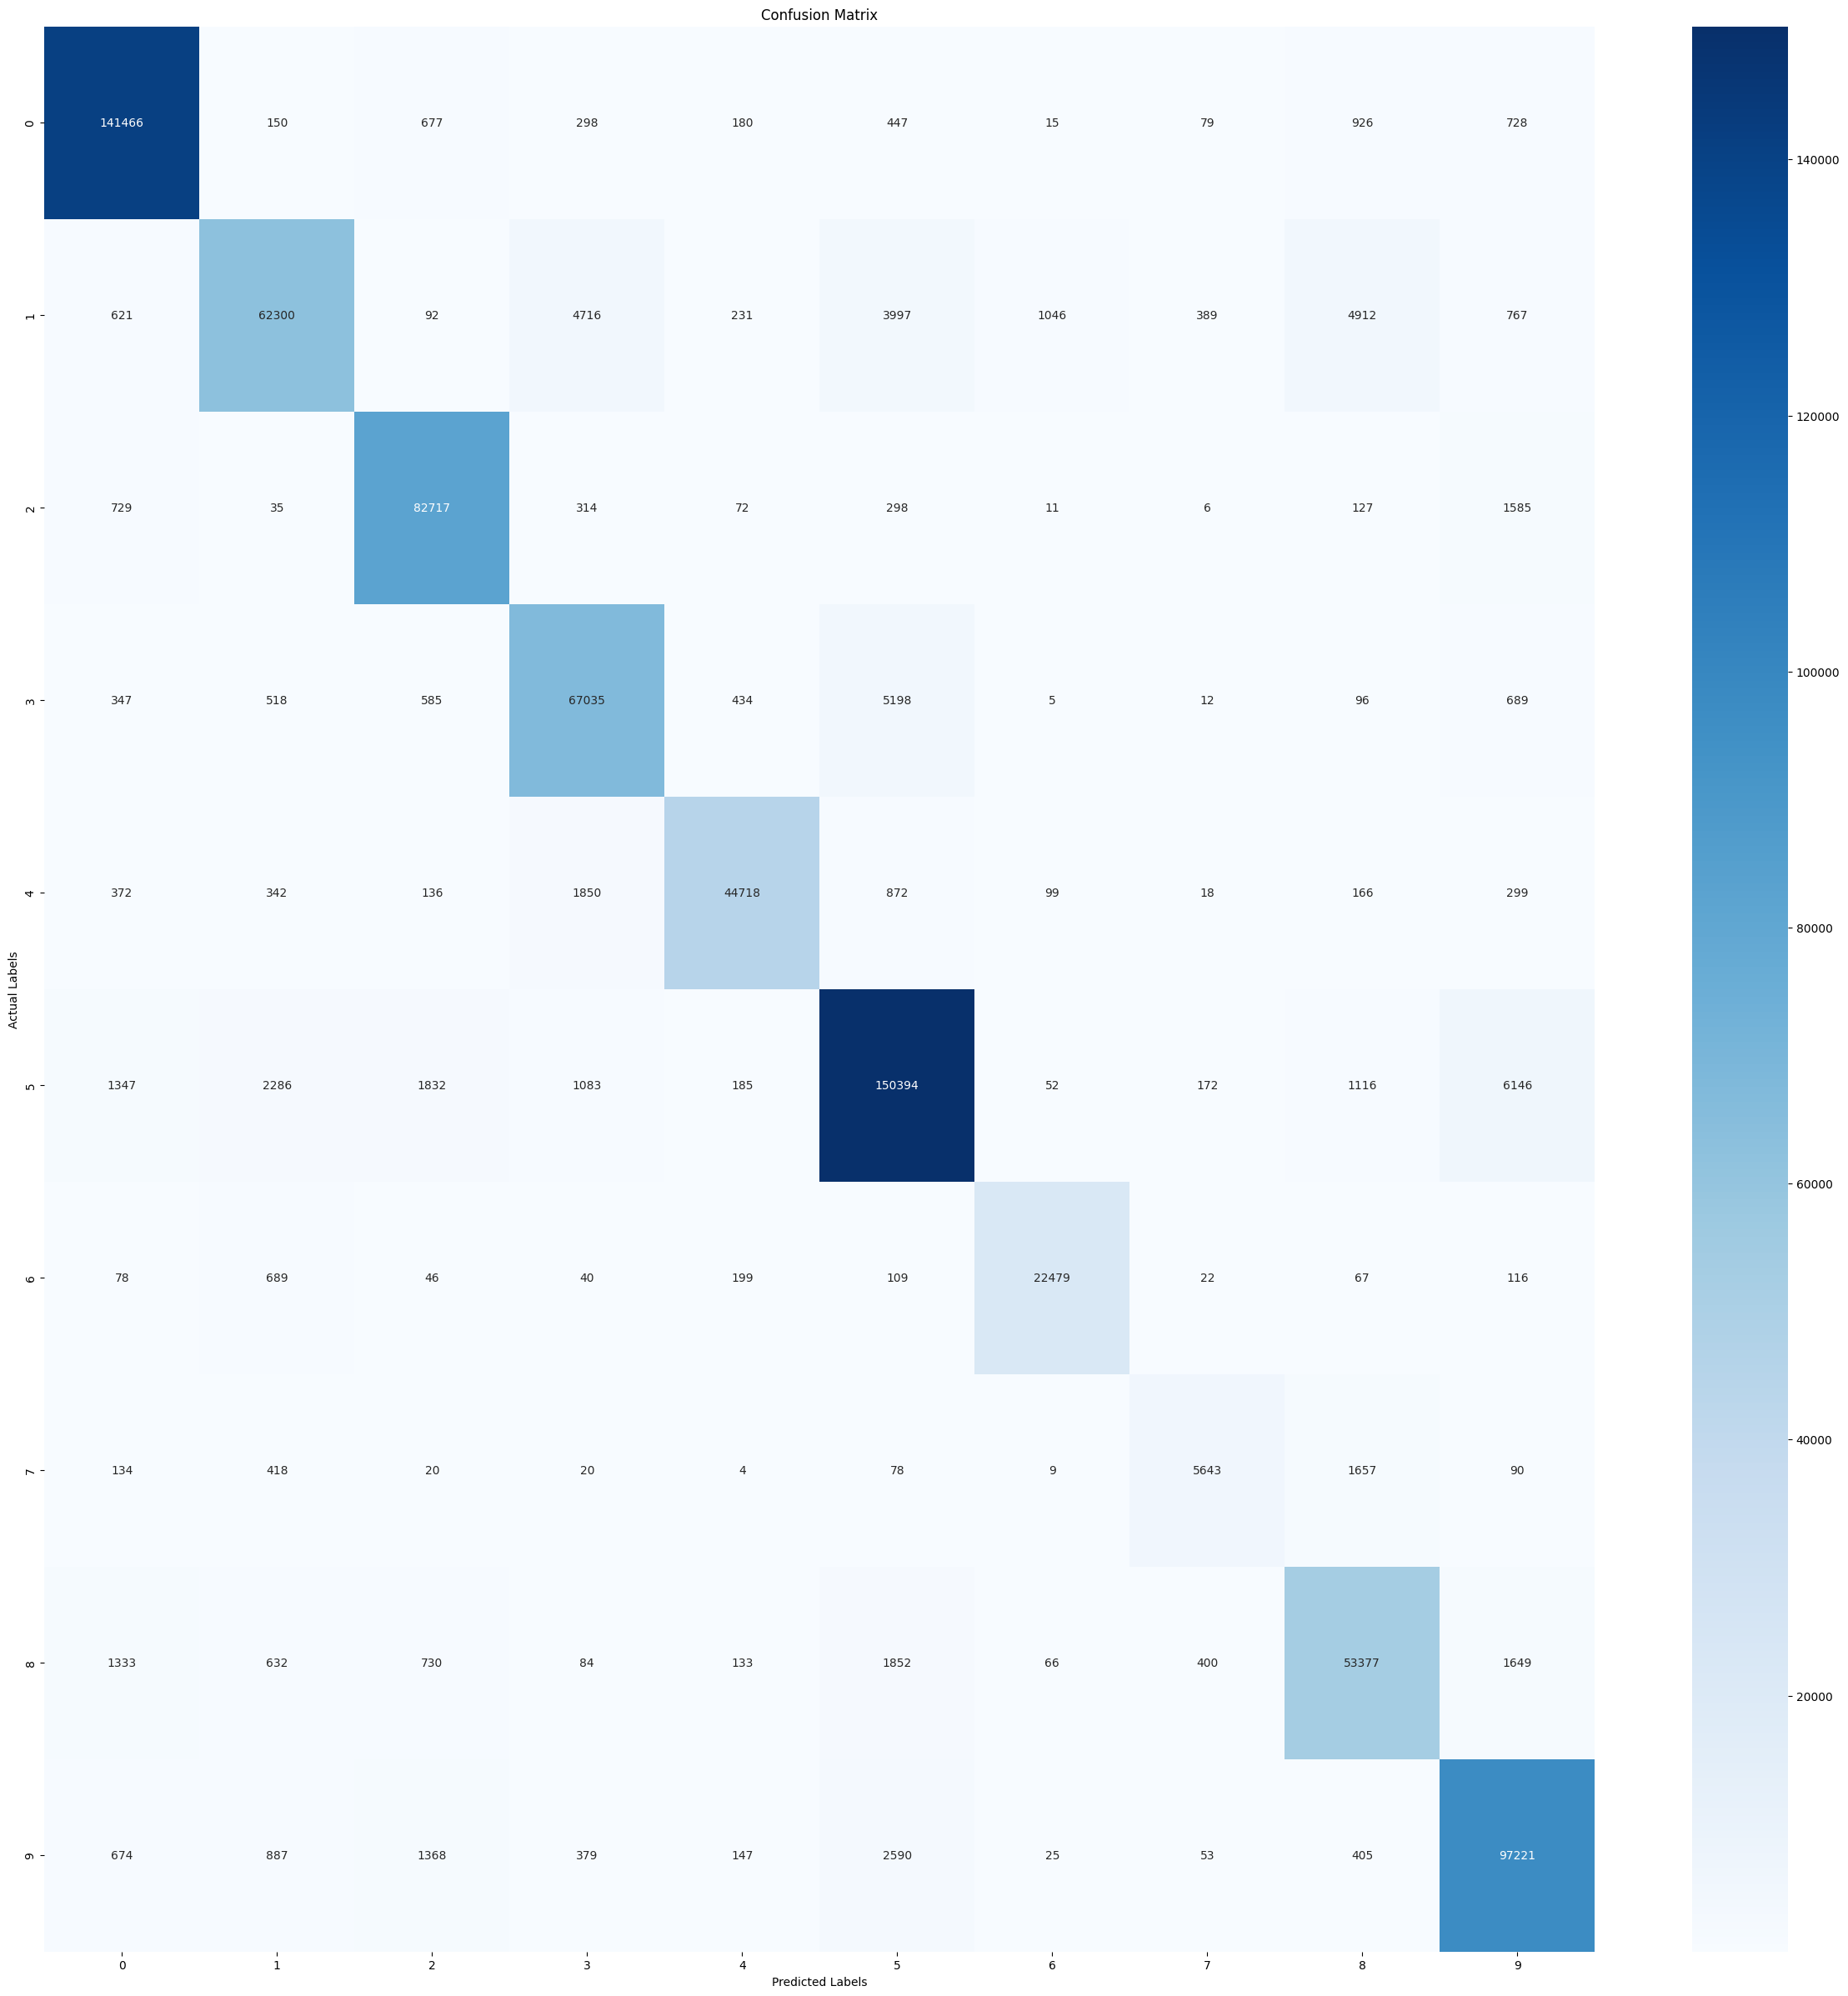

Model saved as model_contrastive=0.5_mask=0.5.pth
Batch 0, features saved to extracted_features_mask_contrastive/features_batch_0.pt, labels saved to extracted_labels_mask_contrastive/labels_batch_0.pt
Batch 1000, features saved to extracted_features_mask_contrastive/features_batch_1000.pt, labels saved to extracted_labels_mask_contrastive/labels_batch_1000.pt
Batch 2000, features saved to extracted_features_mask_contrastive/features_batch_2000.pt, labels saved to extracted_labels_mask_contrastive/labels_batch_2000.pt
Batch 3000, features saved to extracted_features_mask_contrastive/features_batch_3000.pt, labels saved to extracted_labels_mask_contrastive/labels_batch_3000.pt
Batch 4000, features saved to extracted_features_mask_contrastive/features_batch_4000.pt, labels saved to extracted_labels_mask_contrastive/labels_batch_4000.pt
Batch 5000, features saved to extracted_features_mask_contrastive/features_batch_5000.pt, labels saved to extracted_labels_mask_contrastive/labels_batch_5

/root/miniconda3/lib/python3.12/site-packages/torch/optim/lr_scheduler.py:28: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn("The verbose parameter is deprecated. Please use get_last_lr() "


Epoch 0 Batch 1000, Loss: 0.5276272296905518
Epoch 0 Batch 2000, Loss: 0.3602182865142822
Epoch 0 Batch 3000, Loss: 0.36270782351493835
Epoch 0 Batch 4000, Loss: 0.9795174598693848
Epoch 0 Batch 5000, Loss: 0.24187004566192627
Epoch 0 Batch 6000, Loss: 0.3644275665283203
Epoch 0 Batch 7000, Loss: 0.3464154601097107
Epoch 0 Batch 8000, Loss: 0.48862123489379883
Epoch 0 Batch 9000, Loss: 0.5065279006958008
Epoch 0 Batch 10000, Loss: 0.4587469696998596
Epoch 0 Batch 11000, Loss: 0.3714279234409332
Epoch 0 Batch 12000, Loss: 0.17909778654575348
Epoch 0 Batch 13000, Loss: 0.7566424012184143
Epoch 0 Batch 14000, Loss: 0.13789086043834686
Epoch 0 Batch 15000, Loss: 0.5057770013809204
Epoch 0 Batch 16000, Loss: 0.32453101873397827
Epoch 0 Batch 17000, Loss: 0.2848946154117584
Epoch 0 Batch 18000, Loss: 0.3304436504840851
Epoch 0 Batch 19000, Loss: 0.36211666464805603
Epoch 0 Batch 20000, Loss: 0.11818721890449524
Epoch 0 Batch 21000, Loss: 0.45053720474243164
Epoch [1/30], Average Validation L

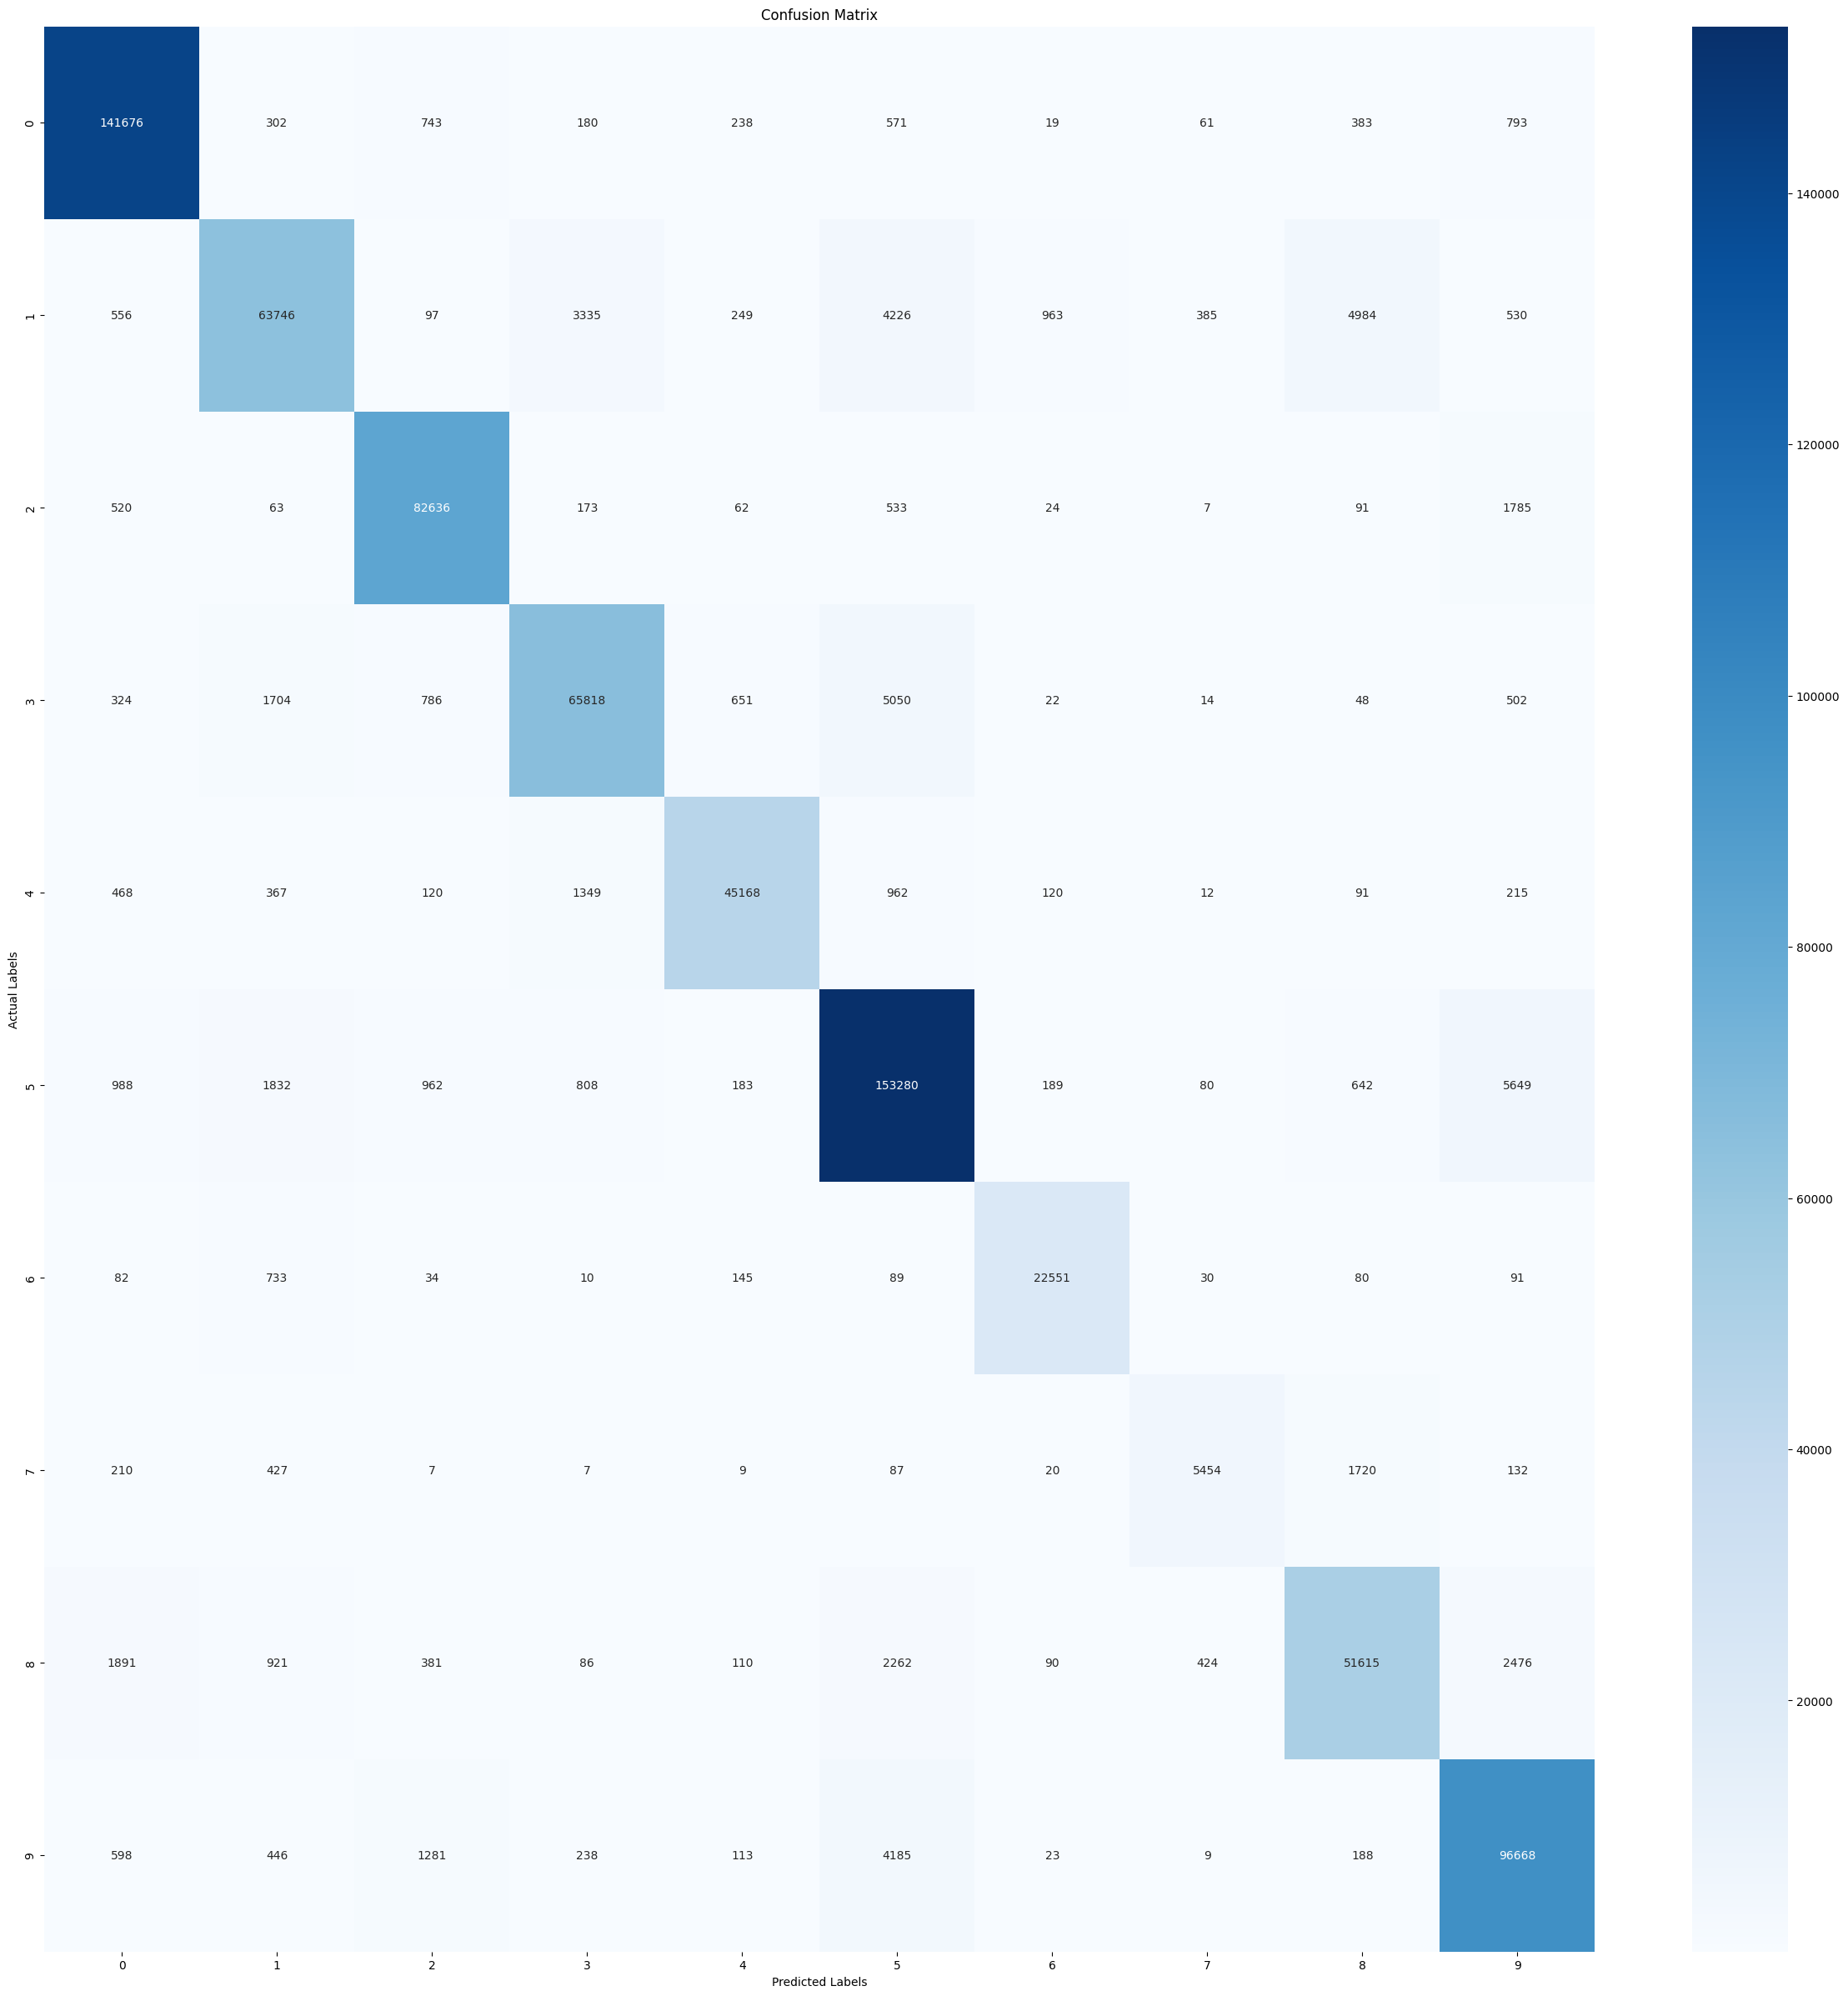

Model saved as model_contrastive=0.4_mask=0.6.pth
Batch 0, features saved to extracted_features_mask_contrastive/features_batch_0.pt, labels saved to extracted_labels_mask_contrastive/labels_batch_0.pt
Batch 1000, features saved to extracted_features_mask_contrastive/features_batch_1000.pt, labels saved to extracted_labels_mask_contrastive/labels_batch_1000.pt
Batch 2000, features saved to extracted_features_mask_contrastive/features_batch_2000.pt, labels saved to extracted_labels_mask_contrastive/labels_batch_2000.pt
Batch 3000, features saved to extracted_features_mask_contrastive/features_batch_3000.pt, labels saved to extracted_labels_mask_contrastive/labels_batch_3000.pt
Batch 4000, features saved to extracted_features_mask_contrastive/features_batch_4000.pt, labels saved to extracted_labels_mask_contrastive/labels_batch_4000.pt
Batch 5000, features saved to extracted_features_mask_contrastive/features_batch_5000.pt, labels saved to extracted_labels_mask_contrastive/labels_batch_5

/root/miniconda3/lib/python3.12/site-packages/torch/optim/lr_scheduler.py:28: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn("The verbose parameter is deprecated. Please use get_last_lr() "


Epoch 0 Batch 0, Loss: 2.319275140762329
Epoch 0 Batch 1000, Loss: 0.37715643644332886
Epoch 0 Batch 2000, Loss: 0.8402442336082458
Epoch 0 Batch 3000, Loss: 0.5207748413085938
Epoch 0 Batch 4000, Loss: 0.4385678768157959
Epoch 0 Batch 5000, Loss: 0.2835444509983063
Epoch 0 Batch 6000, Loss: 0.32630178332328796
Epoch 0 Batch 7000, Loss: 0.2081042230129242
Epoch 0 Batch 8000, Loss: 0.4650895297527313
Epoch 0 Batch 9000, Loss: 0.21220000088214874
Epoch 0 Batch 10000, Loss: 0.580328643321991
Epoch 0 Batch 11000, Loss: 0.43757858872413635
Epoch 0 Batch 12000, Loss: 0.19649390876293182
Epoch 0 Batch 13000, Loss: 0.11121103167533875
Epoch 0 Batch 14000, Loss: 0.6960041522979736
Epoch 0 Batch 15000, Loss: 0.387557715177536
Epoch 0 Batch 16000, Loss: 0.1130402535200119
Epoch 0 Batch 17000, Loss: 0.23674295842647552
Epoch 0 Batch 18000, Loss: 0.3180655241012573
Epoch 0 Batch 19000, Loss: 0.2205708920955658
Epoch 0 Batch 20000, Loss: 0.45274919271469116
Epoch 0 Batch 21000, Loss: 0.3748185038566

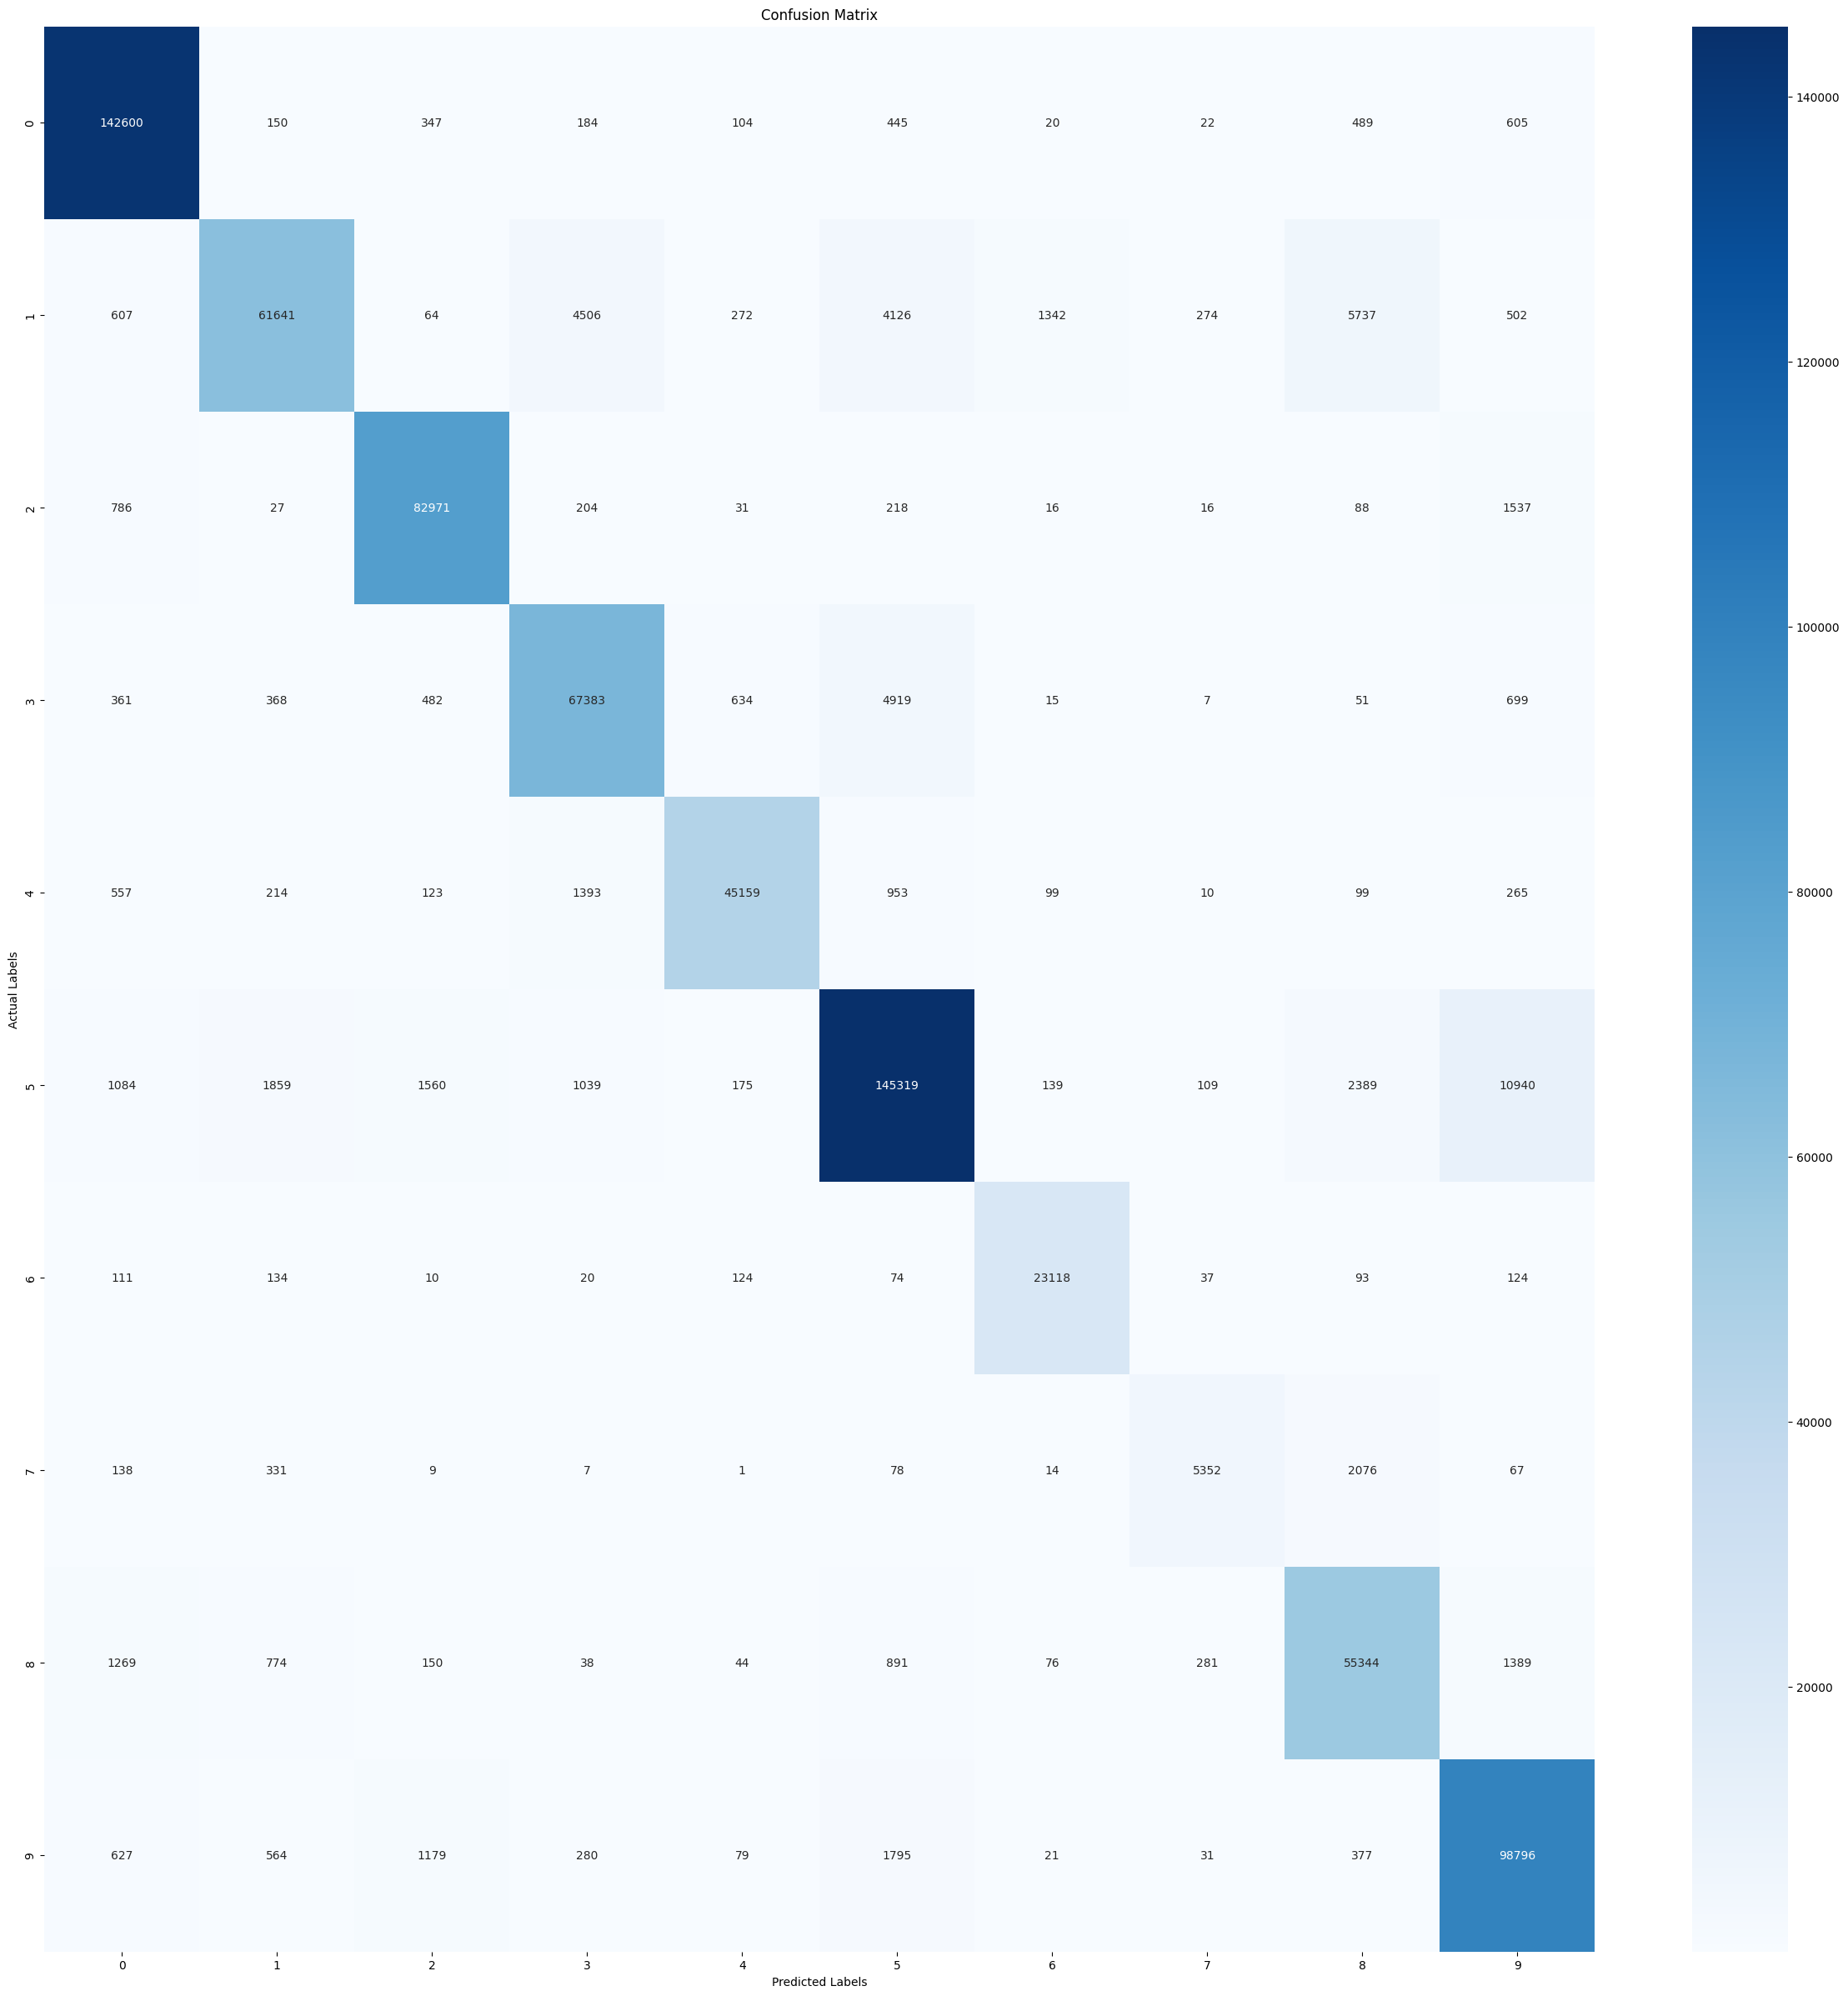

Model saved as model_contrastive=0.3_mask=0.7.pth
Batch 0, features saved to extracted_features_mask_contrastive/features_batch_0.pt, labels saved to extracted_labels_mask_contrastive/labels_batch_0.pt
Batch 1000, features saved to extracted_features_mask_contrastive/features_batch_1000.pt, labels saved to extracted_labels_mask_contrastive/labels_batch_1000.pt
Batch 2000, features saved to extracted_features_mask_contrastive/features_batch_2000.pt, labels saved to extracted_labels_mask_contrastive/labels_batch_2000.pt
Batch 3000, features saved to extracted_features_mask_contrastive/features_batch_3000.pt, labels saved to extracted_labels_mask_contrastive/labels_batch_3000.pt
Batch 4000, features saved to extracted_features_mask_contrastive/features_batch_4000.pt, labels saved to extracted_labels_mask_contrastive/labels_batch_4000.pt
Batch 5000, features saved to extracted_features_mask_contrastive/features_batch_5000.pt, labels saved to extracted_labels_mask_contrastive/labels_batch_5

/root/miniconda3/lib/python3.12/site-packages/torch/optim/lr_scheduler.py:28: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn("The verbose parameter is deprecated. Please use get_last_lr() "


Epoch 0 Batch 0, Loss: 2.323188304901123
Epoch 0 Batch 1000, Loss: 0.41341811418533325
Epoch 0 Batch 2000, Loss: 0.5713531374931335
Epoch 0 Batch 3000, Loss: 0.12669149041175842
Epoch 0 Batch 4000, Loss: 0.8262344598770142
Epoch 0 Batch 5000, Loss: 0.4839111268520355
Epoch 0 Batch 6000, Loss: 0.38029566407203674
Epoch 0 Batch 7000, Loss: 0.29933756589889526
Epoch 0 Batch 8000, Loss: 0.4968174695968628
Epoch 0 Batch 9000, Loss: 0.5398119688034058
Epoch 0 Batch 10000, Loss: 0.4156484305858612
Epoch 0 Batch 11000, Loss: 0.48539650440216064
Epoch 0 Batch 12000, Loss: 0.38797155022621155
Epoch 0 Batch 13000, Loss: 0.42878708243370056
Epoch 0 Batch 14000, Loss: 0.6328908801078796
Epoch 0 Batch 15000, Loss: 0.33079418540000916
Epoch 0 Batch 16000, Loss: 0.4218026399612427
Epoch 0 Batch 17000, Loss: 0.17132414877414703
Epoch 0 Batch 18000, Loss: 0.5601592659950256
Epoch 0 Batch 19000, Loss: 0.2550761103630066
Epoch 0 Batch 20000, Loss: 0.3293505907058716
Epoch 0 Batch 21000, Loss: 0.2472219169

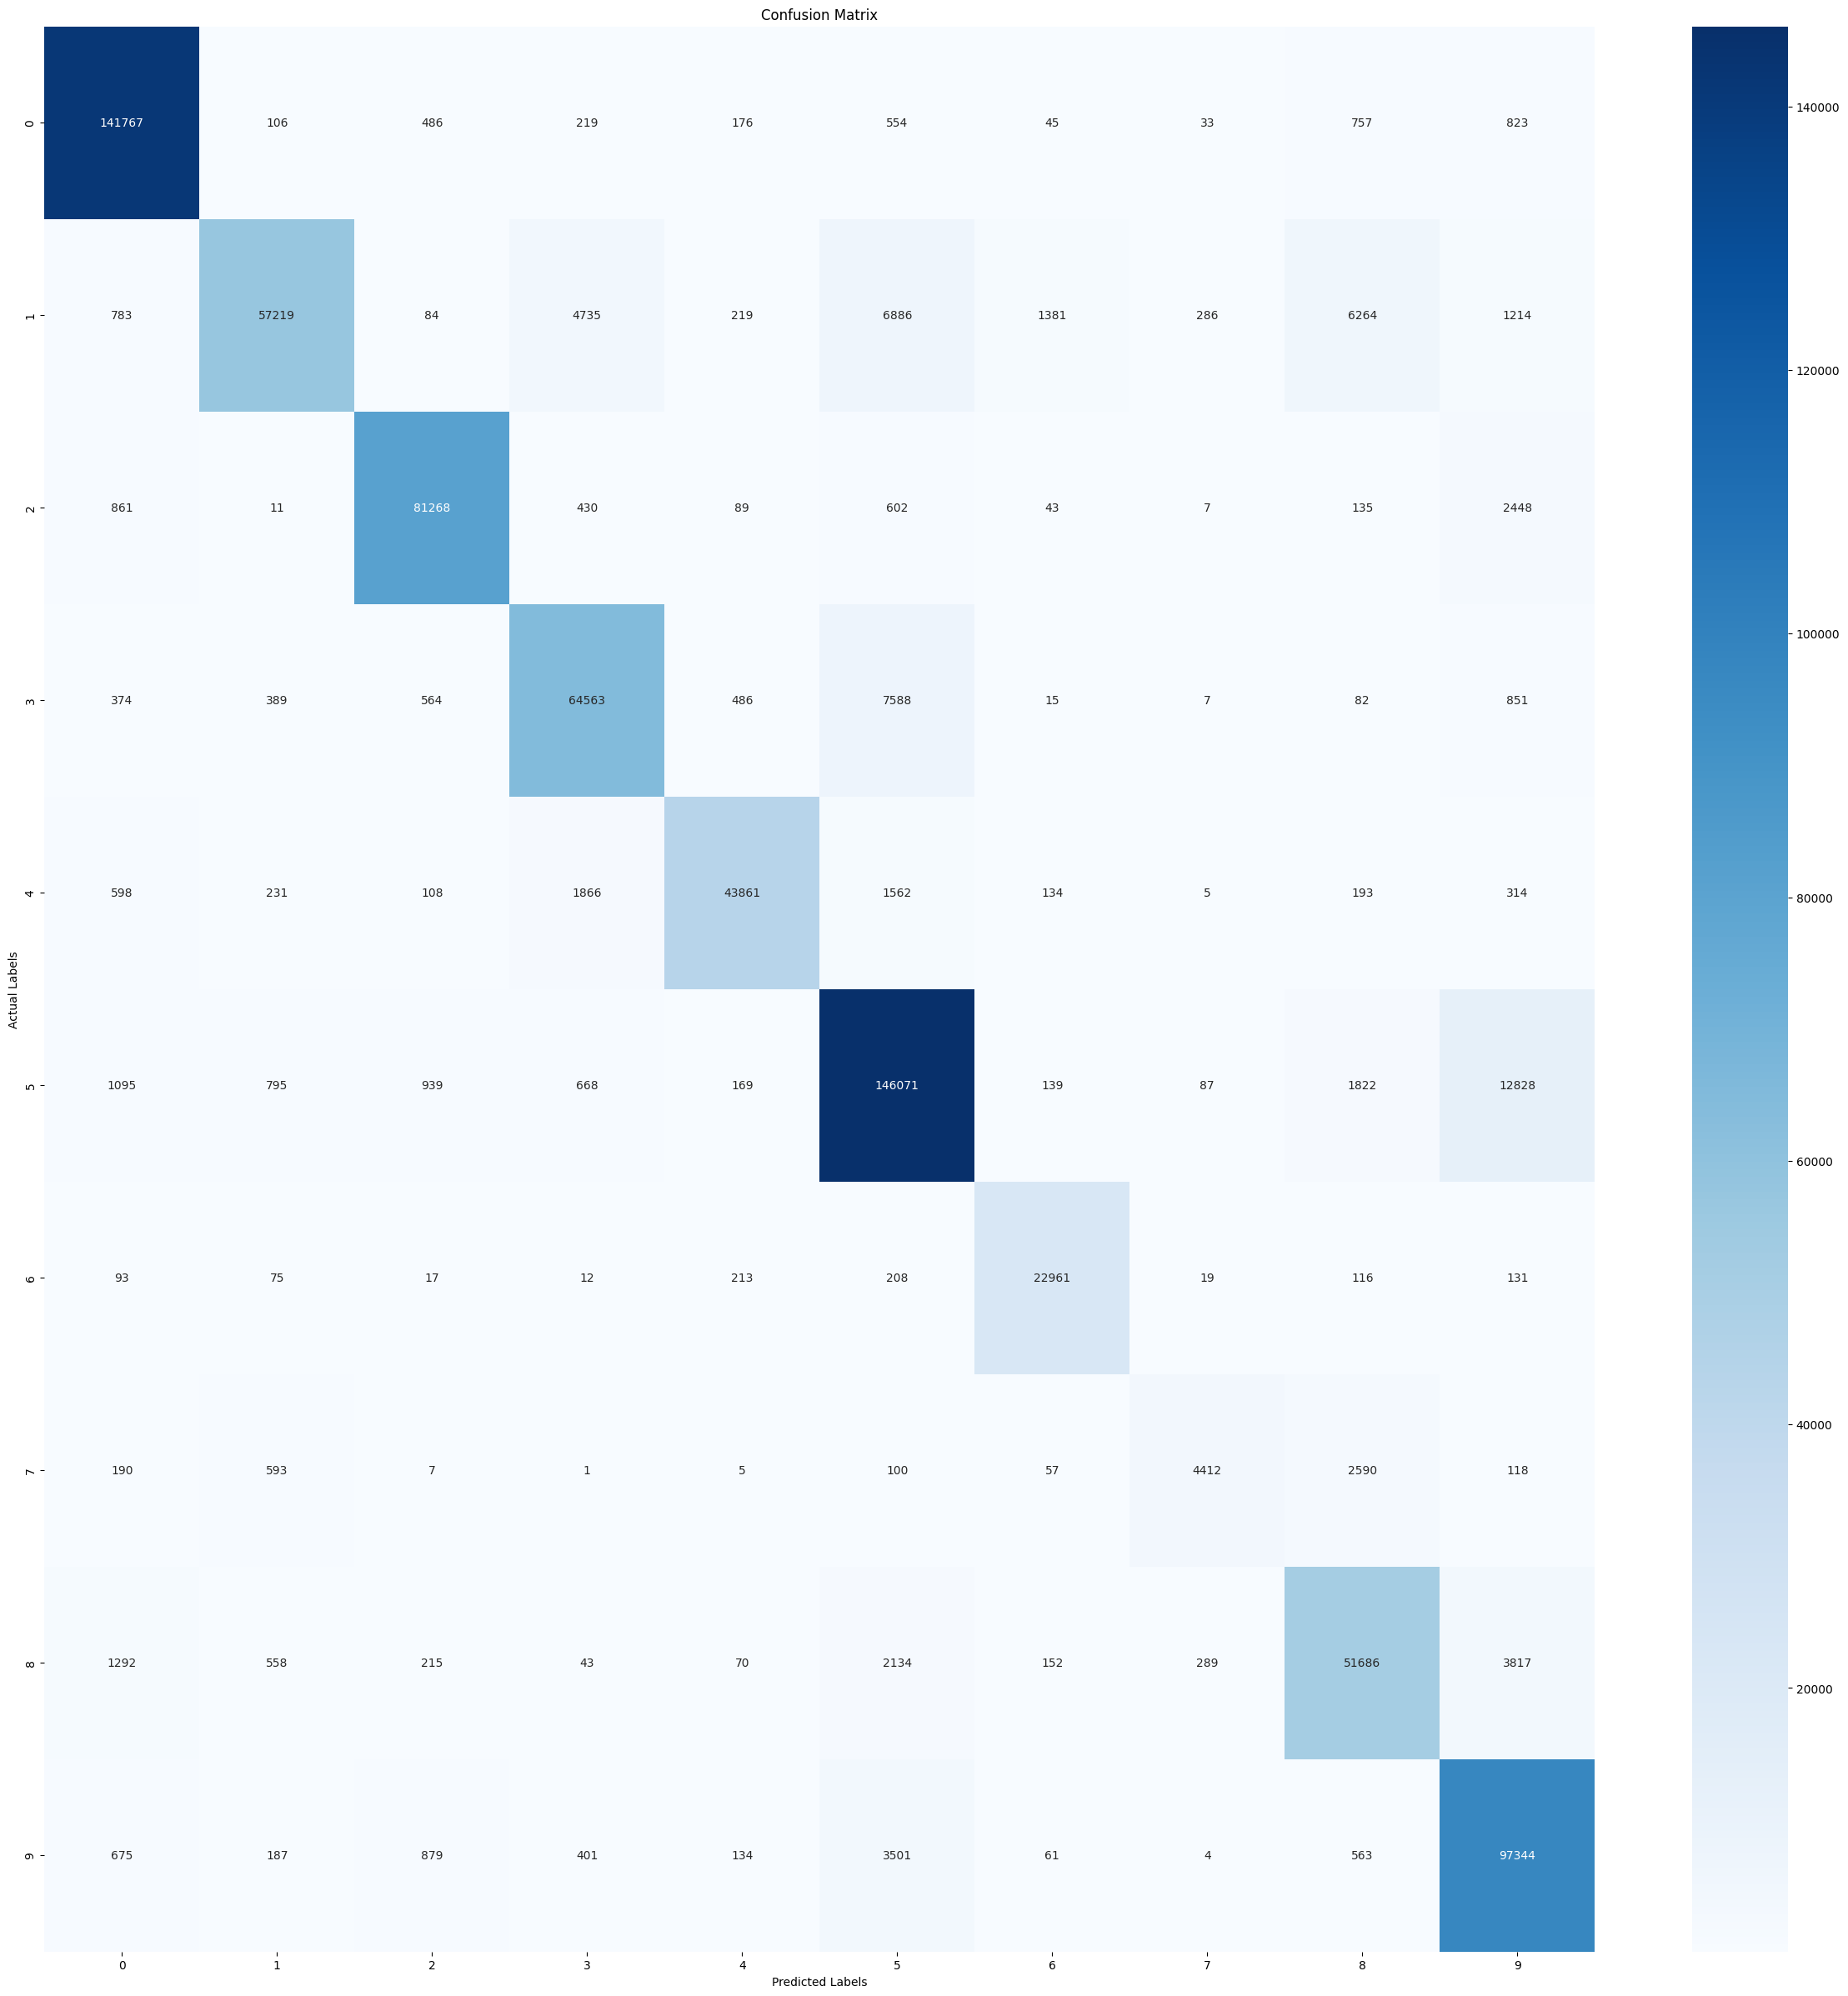

Model saved as model_contrastive=0.2_mask=0.8.pth
Batch 0, features saved to extracted_features_mask_contrastive/features_batch_0.pt, labels saved to extracted_labels_mask_contrastive/labels_batch_0.pt
Batch 1000, features saved to extracted_features_mask_contrastive/features_batch_1000.pt, labels saved to extracted_labels_mask_contrastive/labels_batch_1000.pt
Batch 2000, features saved to extracted_features_mask_contrastive/features_batch_2000.pt, labels saved to extracted_labels_mask_contrastive/labels_batch_2000.pt
Batch 3000, features saved to extracted_features_mask_contrastive/features_batch_3000.pt, labels saved to extracted_labels_mask_contrastive/labels_batch_3000.pt
Batch 4000, features saved to extracted_features_mask_contrastive/features_batch_4000.pt, labels saved to extracted_labels_mask_contrastive/labels_batch_4000.pt
Batch 5000, features saved to extracted_features_mask_contrastive/features_batch_5000.pt, labels saved to extracted_labels_mask_contrastive/labels_batch_5

/root/miniconda3/lib/python3.12/site-packages/torch/optim/lr_scheduler.py:28: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn("The verbose parameter is deprecated. Please use get_last_lr() "


Epoch 0 Batch 0, Loss: 2.304656744003296
Epoch 0 Batch 1000, Loss: 0.5031392574310303
Epoch 0 Batch 2000, Loss: 0.39228522777557373
Epoch 0 Batch 3000, Loss: 0.27337661385536194
Epoch 0 Batch 4000, Loss: 0.4855779707431793
Epoch 0 Batch 5000, Loss: 0.4286159574985504
Epoch 0 Batch 6000, Loss: 0.594222366809845
Epoch 0 Batch 7000, Loss: 0.4229125380516052
Epoch 0 Batch 8000, Loss: 0.5102605223655701
Epoch 0 Batch 9000, Loss: 0.5118913650512695
Epoch 0 Batch 10000, Loss: 0.2729308009147644
Epoch 0 Batch 11000, Loss: 0.45765364170074463
Epoch 0 Batch 12000, Loss: 0.41478151082992554
Epoch 0 Batch 13000, Loss: 0.3171900808811188
Epoch 0 Batch 14000, Loss: 0.04102667421102524
Epoch 0 Batch 15000, Loss: 0.34157100319862366
Epoch 0 Batch 16000, Loss: 0.2417467087507248
Epoch 0 Batch 17000, Loss: 0.3123120069503784
Epoch 0 Batch 18000, Loss: 0.230449840426445
Epoch 0 Batch 19000, Loss: 0.3954847455024719
Epoch 0 Batch 20000, Loss: 0.16270646452903748
Epoch 0 Batch 21000, Loss: 0.21657899022102

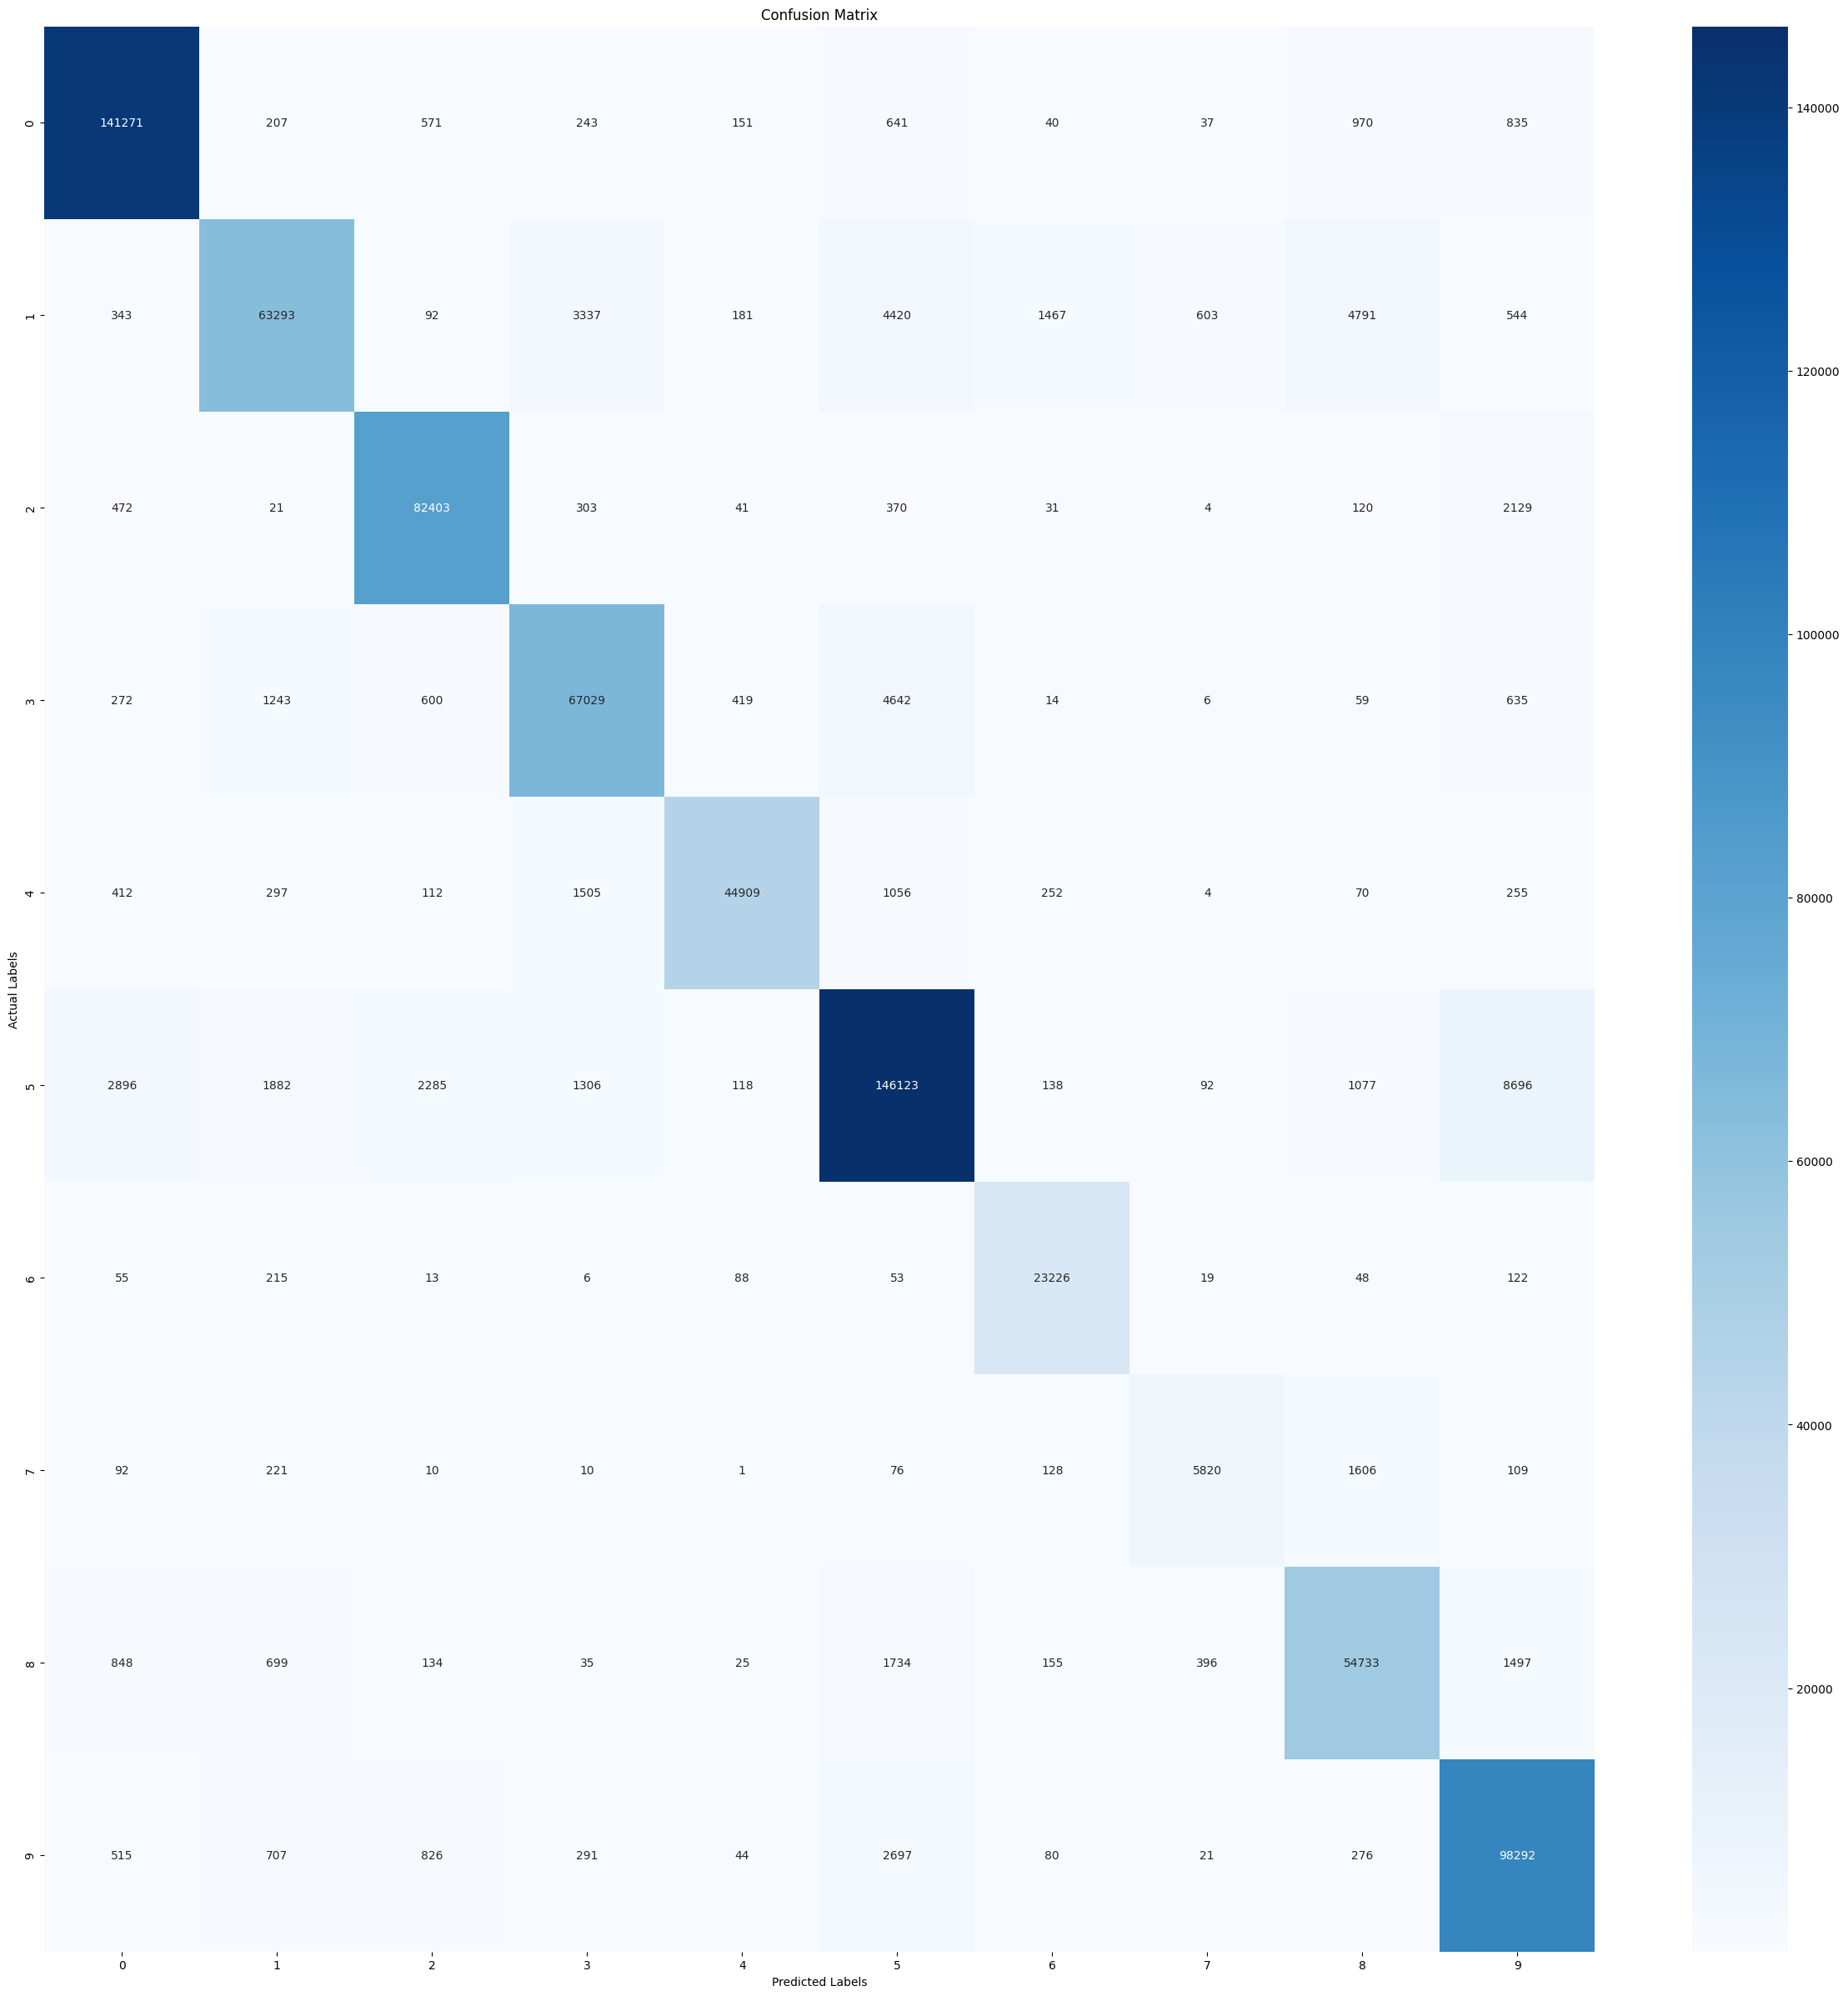

Model saved as model_contrastive=0.1_mask=0.9.pth
Batch 0, features saved to extracted_features_mask_contrastive/features_batch_0.pt, labels saved to extracted_labels_mask_contrastive/labels_batch_0.pt
Batch 1000, features saved to extracted_features_mask_contrastive/features_batch_1000.pt, labels saved to extracted_labels_mask_contrastive/labels_batch_1000.pt
Batch 2000, features saved to extracted_features_mask_contrastive/features_batch_2000.pt, labels saved to extracted_labels_mask_contrastive/labels_batch_2000.pt
Batch 3000, features saved to extracted_features_mask_contrastive/features_batch_3000.pt, labels saved to extracted_labels_mask_contrastive/labels_batch_3000.pt
Batch 4000, features saved to extracted_features_mask_contrastive/features_batch_4000.pt, labels saved to extracted_labels_mask_contrastive/labels_batch_4000.pt
Batch 5000, features saved to extracted_features_mask_contrastive/features_batch_5000.pt, labels saved to extracted_labels_mask_contrastive/labels_batch_5

/root/miniconda3/lib/python3.12/site-packages/torch/optim/lr_scheduler.py:28: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn("The verbose parameter is deprecated. Please use get_last_lr() "


Epoch 0 Batch 0, Loss: 2.3198952674865723
Epoch 0 Batch 1000, Loss: 0.5514715909957886
Epoch 0 Batch 2000, Loss: 0.7237001657485962
Epoch 0 Batch 3000, Loss: 0.47575873136520386
Epoch 0 Batch 4000, Loss: 0.7053611278533936
Epoch 0 Batch 5000, Loss: 0.7352491021156311
Epoch 0 Batch 6000, Loss: 0.6388640403747559
Epoch 0 Batch 7000, Loss: 0.3595978319644928
Epoch 0 Batch 8000, Loss: 0.4749809801578522
Epoch 0 Batch 9000, Loss: 0.2755376398563385
Epoch 0 Batch 10000, Loss: 0.18612058460712433
Epoch 0 Batch 11000, Loss: 0.3703046441078186
Epoch 0 Batch 12000, Loss: 0.30217424035072327
Epoch 0 Batch 13000, Loss: 0.3151455223560333
Epoch 0 Batch 14000, Loss: 0.29064783453941345
Epoch 0 Batch 15000, Loss: 0.6131772398948669
Epoch 0 Batch 16000, Loss: 0.24613375961780548
Epoch 0 Batch 17000, Loss: 0.29207485914230347
Epoch 0 Batch 18000, Loss: 0.5202866196632385
Epoch 0 Batch 19000, Loss: 0.1252196729183197
Epoch 0 Batch 20000, Loss: 0.21419204771518707
Epoch 0 Batch 21000, Loss: 0.34193414449

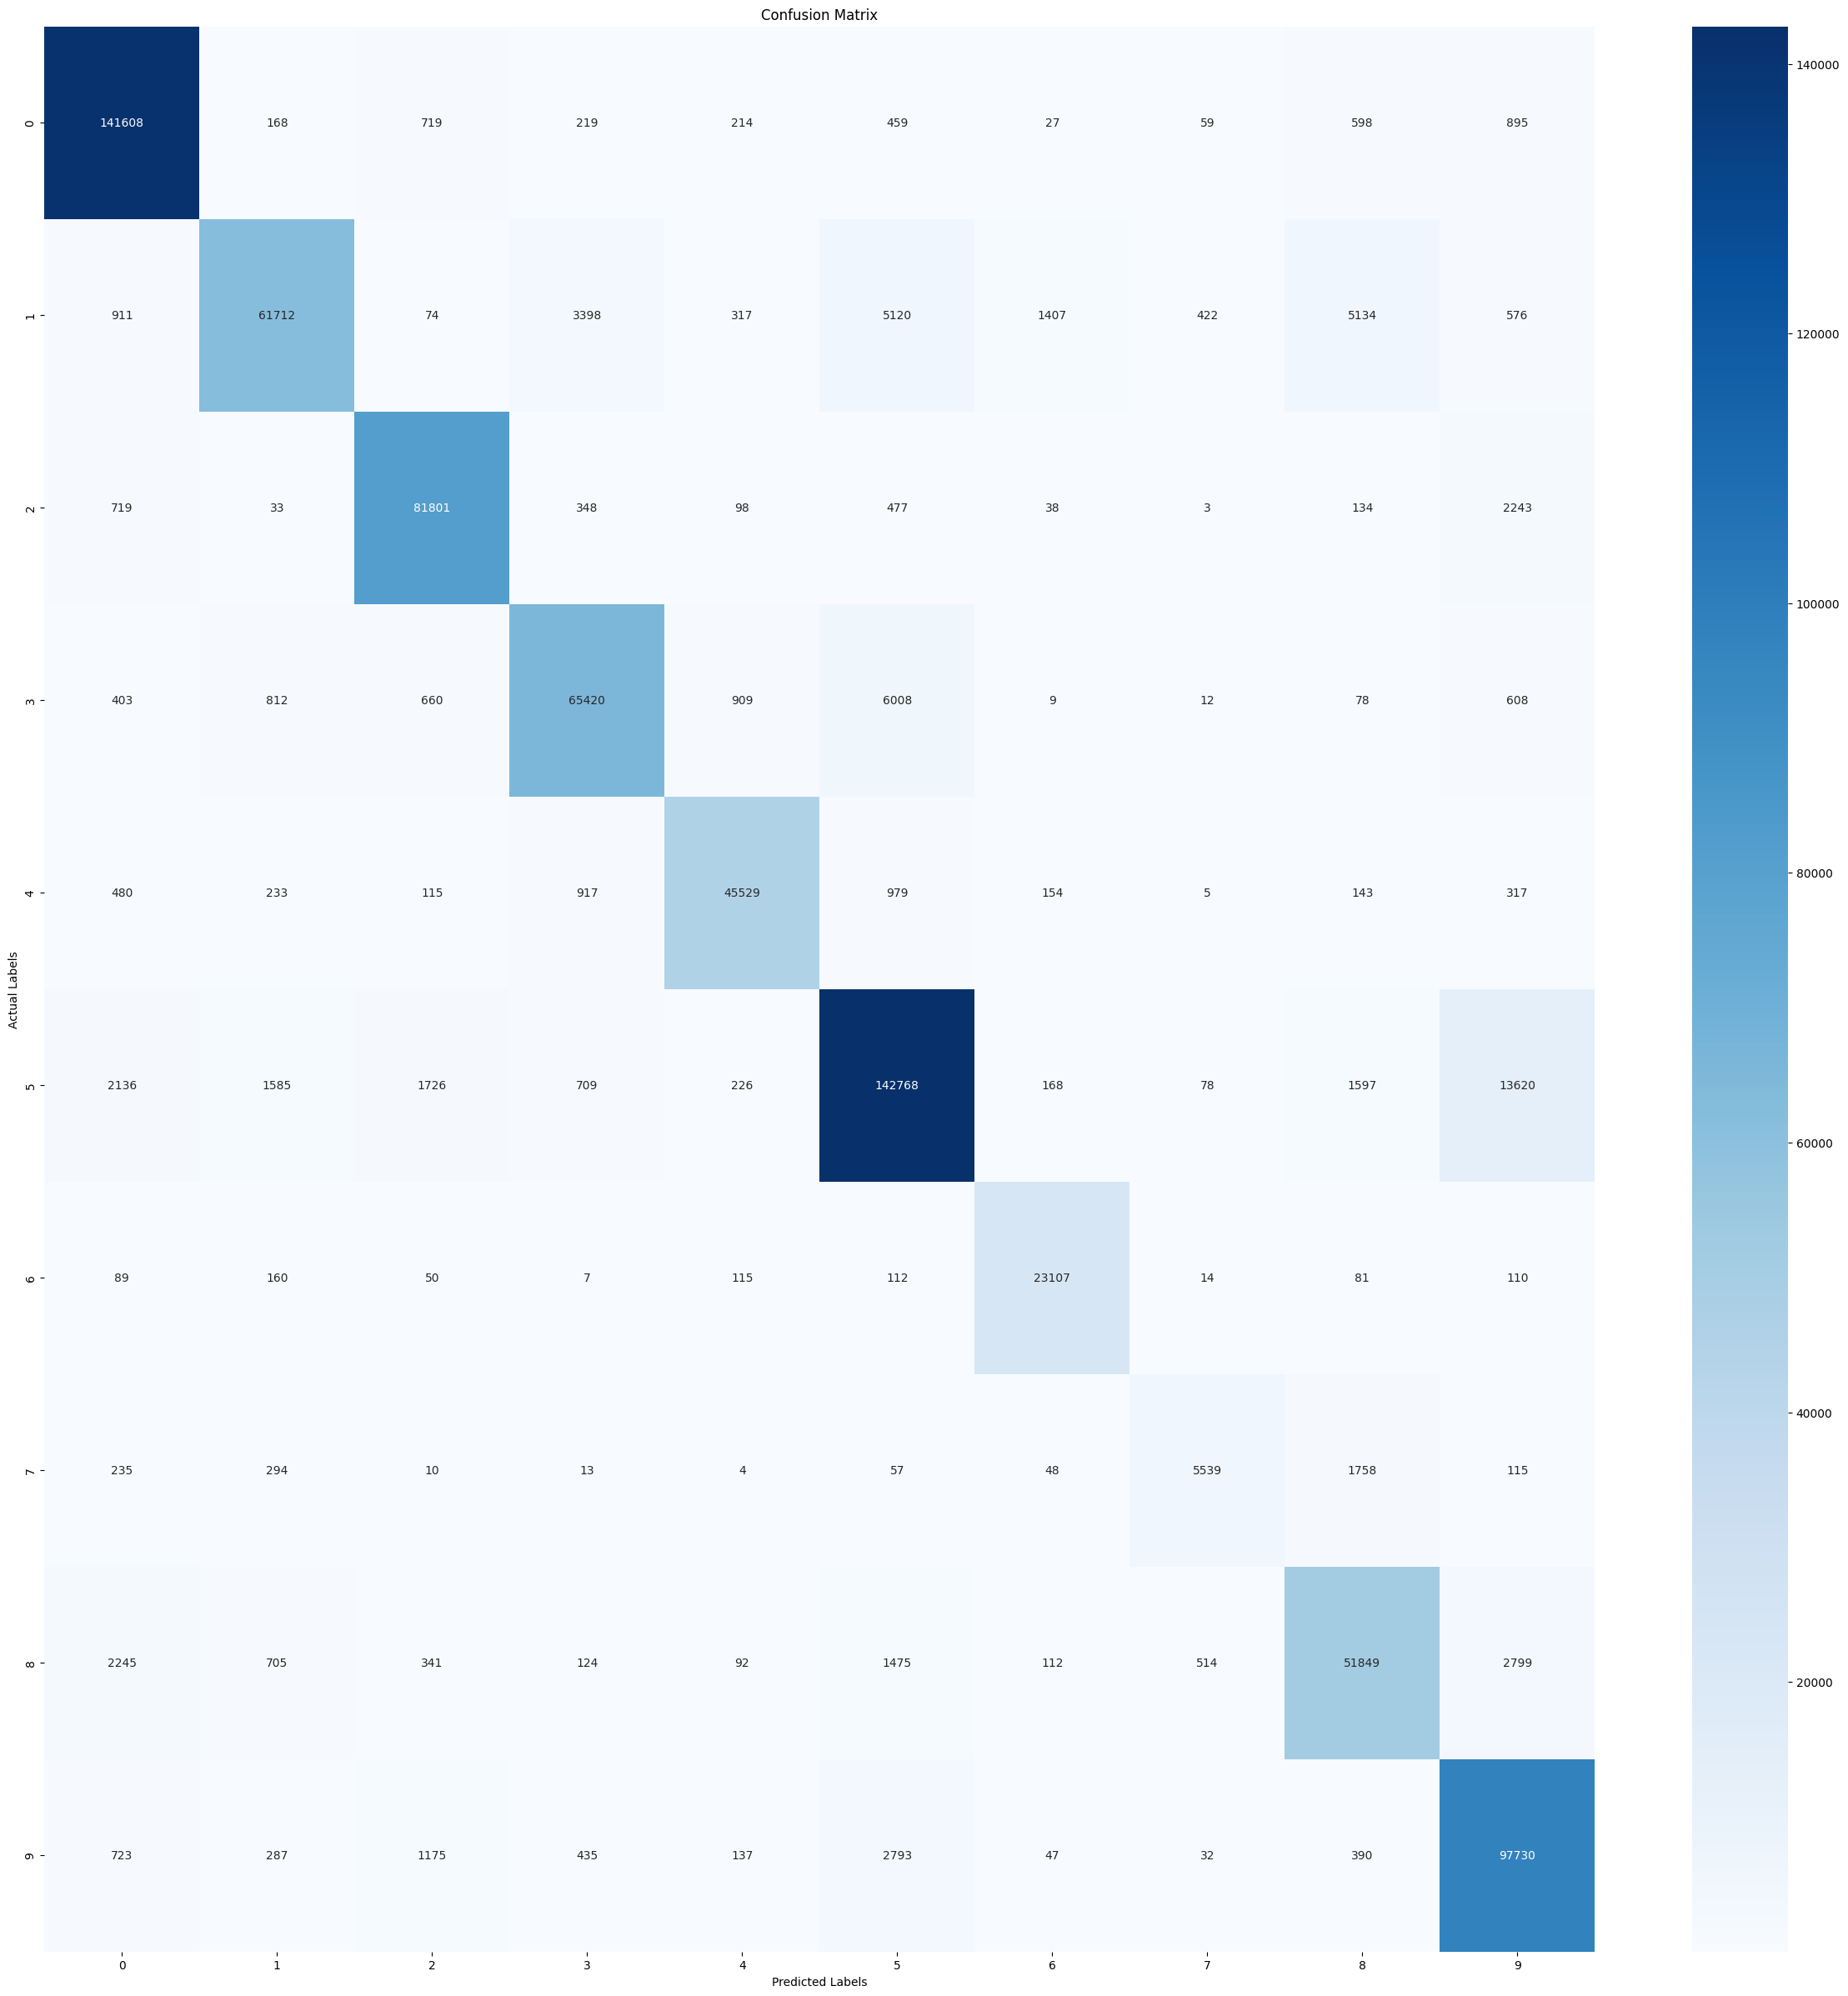

Model saved as model_contrastive=-0.0_mask=1.0.pth


FileNotFoundError: [Errno 2] No such file or directory: 'model_contrastive=-0.0_mask=1.0.pth'

In [2]:
weights = np.arange(0.3, 1.1, 0.1)

for mask_weight in weights:
    contrastive_weight = 1 - mask_weight  
    import os
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model = MaskModel(hidden_dim_mask=100, num_layers=2)

    model.to(device)
    model_name = f'model_contrastive={contrastive_weight:.1f}_mask={mask_weight:.1f}.pth'
    #model_name = 'mask_model_and_contrastive.pth' 
    print(f"Model saved as {model_name}")
    # Assuming the model and data_loader are already defined and initialized as per your setup
    model.load_state_dict(torch.load(model_name))
    model.eval()

    # Directory setup
    features_dir = 'extracted_features_mask_contrastive'
    labels_dir = 'extracted_labels_mask_contrastive'
    os.makedirs(features_dir, exist_ok=True)
    os.makedirs(labels_dir, exist_ok=True)

    with torch.no_grad():
        for i, (_,ppi, additional_features, labels) in enumerate(train_dl):
            # Data pre-processing steps you mentioned
            ppi = torch.from_numpy(ppi).transpose(1, 2).to(device)
            labels = torch.from_numpy(labels).to(device)
            flattened_ppi = ppi.flatten(start_dim=-2).to(device)      

            masked_ppi = mask_data(ppi).to(device)
            #shuffling sequences
            
            # Extract features using the modelhow to 
            mask_features = model.extract_features(masked_ppi)
            
            mask_features = mask_features.flatten(start_dim=-2)
            
            concatenated_features = torch.cat((flattened_ppi, mask_features), dim=1)
            
            # Save the features and labels to disk
            features_path = os.path.join(features_dir, f'features_batch_{i}.pt')
            labels_path = os.path.join(labels_dir, f'labels_batch_{i}.pt')
            torch.save(concatenated_features, features_path)
            torch.save(labels, labels_path)

            if i % 1000 == 0:
                print(f"Batch {i}, features saved to {features_path}, labels saved to {labels_path}")



    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model = MaskModel(hidden_dim_mask=100, num_layers=2)
    model.to(device)
    # Assuming the model and data_loader are already defined and initialized as per your setup
    model.load_state_dict(torch.load(model_name))
    model.eval()
    # Directory setup
    features_dir = 'extracted_features_val_mask_contrastive'
    labels_dir = 'extracted_labels_val_mask_contrastive'
    os.makedirs(features_dir, exist_ok=True)
    os.makedirs(labels_dir, exist_ok=True)

    with torch.no_grad():
        for i, (_,ppi, additional_features, labels) in enumerate(val_dl):
            # Data pre-processing steps you mentioned
            ppi = torch.from_numpy(ppi).transpose(1, 2).to(device)
            labels = torch.from_numpy(labels)
            flattened_ppi = ppi.flatten(start_dim=-2)        
                    #masking ppi and negative sequences
            masked_ppi = mask_data(ppi)
            
        
            # Extract features using the model
            mask_features = model.extract_features(masked_ppi)
            #print(mask_features.size())
            mask_features = mask_features.flatten(start_dim=-2)
            #print(mask_features.size())
            concatenated_features = torch.cat((flattened_ppi,  mask_features), dim=1)
            
            # Save the features and labels to disk
            features_path = os.path.join(features_dir, f'features_batch_val_{i}.pt')
            labels_path = os.path.join(labels_dir, f'labels_batch_val_{i}.pt')
            torch.save(concatenated_features, features_path)
            torch.save(labels, labels_path)

            if i % 1000 == 0:
                print(f"Batch {i}, features saved to {features_path}, labels saved to {labels_path}")



    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print(device)
    model = MaskModel(hidden_dim_mask=100, num_layers=2)

    model.to(device)
    # Assuming the model and data_loader are already defined and initialized as per your setup
    model.load_state_dict(torch.load(model_name))
    model.eval()

    # Directory setup
    features_dir = 'extracted_features_test_mask_contrastive'
    labels_dir = 'extracted_labels_test_mask_contrastive'
    os.makedirs(features_dir, exist_ok=True)
    os.makedirs(labels_dir, exist_ok=True)

    with torch.no_grad():
        for i, (_,ppi, additional_features, labels) in enumerate(test_dl):
            # Data pre-processing steps you mentioned
            print(i)
            ppi = torch.from_numpy(ppi).transpose(1, 2).to(device)
            labels = torch.from_numpy(labels).to(device)
            flattened_ppi = ppi.flatten(start_dim=-2).to(device)      # Other steps as per your code...

            masked_ppi = mask_data(ppi).to(device)
            #shuffling sequences
            
            # Extract features using the modelhow to 
            mask_features = model.extract_features(masked_ppi)
            
            mask_features = mask_features.flatten(start_dim=-2)
            #print(mask_features.size())
            concatenated_features = torch.cat((flattened_ppi, mask_features), dim=1)
            
            # Save the features and labels to disk
            features_path = os.path.join(features_dir, f'features_batch_test_{i}.pt')
            labels_path = os.path.join(labels_dir, f'labels_batch_test_{i}.pt')
            torch.save(concatenated_features, features_path)
            torch.save(labels, labels_path)

            if i % 1000 == 0:
                print(f"Batch {i}, features saved to {features_path}, labels saved to {labels_path}")



    from torch.utils.data import Dataset

    import torch

    class NetFlowDataset(Dataset):
        def __init__(self, features_dir, labels_dir):
            self.features_files = [os.path.join(features_dir, f) for f in sorted(os.listdir(features_dir))]
            self.labels_files = [os.path.join(labels_dir, f) for f in sorted(os.listdir(labels_dir))]
            
            assert len(self.features_files) == len(self.labels_files), "Mismatched number of features and labels files."

        def __len__(self):
            return len(self.features_files)

        def __getitem__(self, idx):
            features = torch.load(self.features_files[idx])
            labels = torch.load(self.labels_files[idx])
            return features, labels


    dataset_features_val = NetFlowDataset('extracted_features_val_mask_contrastive','extracted_labels_val_mask_contrastive')


    dataloader_features_val = DataLoader(dataset_features_val, batch_size=1, shuffle=True)

    # Initialize your dataset
    dataset_features = NetFlowDataset('extracted_features_mask_contrastive', 'extracted_labels_mask_contrastive')

    # Initialize DataLoader
    dataloader_features = DataLoader(dataset_features, batch_size=1, shuffle=True)


    dataset_features_test = NetFlowDataset('extracted_features_test_mask_contrastive','extracted_labels_test_mask_contrastive')


    dataloader_features_test = DataLoader(dataset_features_test, batch_size=1, shuffle=True)


    class Classifier(nn.Module):
        def __init__(self, input_size, output_size):
            super().__init__()

            # Encoder: Transforms the input feature vector into a lower-dimensional space
            self.encoder = nn.Sequential(
                nn.Linear(input_size, 512),
                nn.ReLU(),
                nn.Linear(512, 256),
                nn.ReLU(),
                

                
            
            )

            # Classifier: Outputs a logit for each class
            self.classifier = nn.Sequential(
                nn.Linear(256, output_size),
                # Note: No softmax here, as nn.CrossEntropyLoss will handle it
            )

        def forward(self, x):
            encoded = self.encoder(x)
            logits = self.classifier(encoded)
            return logits



    def class_loss(predictions, ground_truth):
        """
        Custom loss function that calculates loss for each sample individually and then computes the mean.
        
        Args:
        - predictions: Tensor of shape [batch_size, n_classes], with raw scores for each class.
        - ground_truth: Tensor of shape [batch_size], with the indices of the correct class for each sample.
        
        Returns:
        - loss: Scalar tensor representing the mean loss value across the batch.
        """
        # Initialize a tensor to store individual losses
        individual_losses = torch.zeros(predictions.size(0))
        
        for i in range(predictions.size(0)):
            # Compute the loss for each sample individually
            
            individual_loss = F.cross_entropy(predictions[i].unsqueeze(0), ground_truth[i].unsqueeze(0))
            
            individual_losses[i] = individual_loss
        
        # Compute the mean of the individual losses
        mean_loss = torch.mean(individual_losses)
        
        return mean_loss

    import torch
    import torch.nn as nn
    import torch.optim as optim
    from sklearn.metrics import confusion_matrix
    import matplotlib.pyplot as plt
    import seaborn as sns
    import numpy as np

    # Assuming Classifier is defined
    # Assuming dataloader_features and dataloader_features_val are defined

    device = torch.device("cpu")

    classifier = Classifier(input_size=3090, output_size= 10).to(device)
    criterion = nn.CrossEntropyLoss()  # Appropriate for classification tasks
    optimizer = optim.Adam(classifier.parameters(), lr=0.001)

    # Learning rate scheduler
    scheduler = ReduceLROnPlateau(optimizer, 'min', factor=0.1, patience=2, verbose=True)

    num_epochs = 30
    patience = 2
    best_val_loss = float('inf')
    epochs_without_improvement = 0




    for epoch in range(num_epochs):
        classifier.train()
        train_losses = []

        for i, (features, labels) in enumerate(dataloader_features):
            features, labels = features.to(device), labels.to(device)
            
            optimizer.zero_grad()
            logits = classifier(features)
            
            logits = logits.squeeze(0)
            
            
            labels = labels.flatten(start_dim= -2)
            
            loss = class_loss(logits, labels)
            loss.backward()
            optimizer.step()
            
            train_losses.append(loss.item())

            if i % 1000 == 0:
                print(f"Epoch {epoch} Batch {i}, Loss: {loss.item()}")

        # Validation phase
        classifier.eval()
        all_preds = []
        all_labels = []
        total_accuracy = 0
        batches = 0
        val_losses = []
        with torch.no_grad():
            for i, (features, labels) in enumerate(dataloader_features_val):
                features, labels = features.to(device), labels.to(device)
                logits = classifier(features)
                logits = logits.squeeze(0)
                labels = labels.flatten(start_dim= -2)
                
                val_loss = class_loss(logits, labels)
                val_losses.append(val_loss.item())
                predicted_labels = torch.argmax(logits, dim=1)
                apps = dataset.get_known_apps()
                batches +=1
    
            
            
                predicted_apps = [apps[idx] for idx in predicted_labels]
                actual_apps = [apps[idx] for idx in labels]

                
                all_preds.extend(predicted_labels.cpu().numpy())
                all_labels.extend(labels.cpu().numpy())
        
                # Compare predicted labels with actual labels
                correct_predictions = (predicted_labels == labels).sum().item()
                total_predictions = labels.size(0)
                accuracy = correct_predictions / total_predictions
                total_accuracy += accuracy
            
            if i % 1000 == 0:
                print(f"Batch {i}, loss: {loss.item()}")
                print(f"Predicted labels: {predicted_apps}")
                print(f"Actual labels: {actual_apps}\n")
                print(f"Accuracy: {accuracy * 100:.2f}%\n")            

            if i % 1000 == 0:
                print(f"Validation - Batch {i}, Loss: {val_loss.item()}")
                print(f"Predicted labels: {predicted_apps}")
                print(f"Actual labels: {actual_apps}\n")
                

        avg_val_loss = np.mean(val_losses)
        print(f"Epoch [{epoch+1}/{num_epochs}], Average Validation Loss: {avg_val_loss}")
        print(f"Validation - Batch {i}, Loss: {val_loss.item()}")
        
        print(f"Average accuracy: {total_accuracy/batches * 100:.2f}%")

        scheduler.step(avg_val_loss)

        # Early stopping check
        if avg_val_loss < best_val_loss:
            best_val_loss = avg_val_loss
            epochs_without_improvement = 0
            torch.save(classifier.state_dict(), 'best_mask_classifier.pth')
        else:
            epochs_without_improvement += 1
            if epochs_without_improvement >= patience:
                print(f"Stopping early at epoch {epoch+1}. No improvement in validation loss for {patience} consecutive epochs. Best Loss: {best_val_loss:.4f}.")
                break

    
    # Load the best model
    print(f"Average accuracy: {total_accuracy/batches * 100:.2f}%")
    


    from sklearn.metrics import precision_score, recall_score, f1_score, confusion_matrix
    import matplotlib.pyplot as plt
    import seaborn as sns
    # Load the best saved model weights
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    classifier = Classifier(input_size=3090, output_size=10).to(device)
    classifier.load_state_dict(torch.load('best_mask_classifier.pth'))
    classifier.eval()  # Set the model to evaluation mode

    test_losses = []
    all_preds_test = []
    all_labels_test = []
    total_accuracy_test = 0
    batches = 0

    with torch.no_grad():
        for i, (features, labels) in enumerate(dataloader_features_test):
            features, labels = features.to(device), labels.to(device)
            logits = classifier(features)
        
            logits = logits.squeeze(0)
            labels = labels.flatten(start_dim= -2)
            
            test_loss = class_loss(logits, labels)
            
            
            test_losses.append(test_loss.item())

            predicted_labels = torch.argmax(logits, dim=1)
            all_preds_test.extend(predicted_labels.cpu().numpy())
            all_labels_test.extend(labels.cpu().numpy())

            # Accuracy calculation
            correct_predictions = (predicted_labels == labels).sum().item()
            total_predictions = labels.size(0)
            accuracy = correct_predictions / total_predictions
            total_accuracy_test += accuracy
            batches += 1
            print(i)

    avg_test_loss = np.mean(test_losses)
    print(f"Average Test Loss: {avg_test_loss}")
    print(f"Average Test Accuracy: {total_accuracy_test/batches * 100:.2f}%")
    print(f"Model saved as {model_name}")


    # Precision, Recall, and F1 Score
    precision = precision_score(all_labels_test, all_preds_test, average='weighted')
    recall = recall_score(all_labels_test, all_preds_test, average='weighted')
    f1 = f1_score(all_labels_test, all_preds_test, average='weighted')

    print(f'Precision: {precision:.4f}, Recall: {recall:.4f}, F1 Score: {f1:.4f}')

    # Confusion Matrix
    cm = confusion_matrix(all_labels_test, all_preds_test)
    plt.figure(figsize=(30,30))
    sns.heatmap(cm, annot=True, fmt="d", cmap='Blues')
    plt.ylabel('Actual Labels')
    plt.xlabel('Predicted Labels')
    plt.title('Confusion Matrix')
    plt.show()
del model, optimizer, scheduler
torch.cuda.empty_cache()